### Create the main dissertation comparison figures in Notebook 07 using the 118 held-out questions:

- Recall@k curves across the five frozen methods.

- Complete and partial retrieval performance.

- Evidence coverage.

- Fixed-\(k\) versus fixed-token-budget results.

- Retrieval latency, returned tokens and indexing workload.

- Paired uncertainty/significance comparisons.

In [2]:
# Force Transformers to use PyTorch only.
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"

print("Transformers backend: PyTorch only")

Transformers backend: PyTorch only


In [3]:
# Initialise the held-out single-passage evaluation.
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
from llama_index.core import Document
import os, platform, socket, torch
from importlib.metadata import version
from time import perf_counter
from transformers.utils import logging as transformers_logging
from datetime import datetime, timezone
from matplotlib.ticker import PercentFormatter

from llama_index.core import Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from transformers import AutoTokenizer


import warnings
warnings.filterwarnings("ignore")  # suppress all warnings

In [56]:
# Validate known inputs and locate existing text-document directories.
PROJECT_ROOT = Path("/data/home/zll/xh0862/esg_rag_project").resolve()
PARSED_FOLDER = PROJECT_ROOT / "data" / "parsed"
BENCHMARK_FOLDER = PROJECT_ROOT / "outputs" / "qa_benchmark"

FROZEN_PATH = BENCHMARK_FOLDER / "frozen_chunking_configurations_2.4.1.json"
EVALUATION_QA_PATH = BENCHMARK_FOLDER / "evaluation_qa_benchmark_2.3.5-final.jsonl"
EVALUATION_EVIDENCE_PATH = BENCHMARK_FOLDER / "evaluation_qa_evidence_2.3.5-final.jsonl"

def load_jsonl(path):
    with path.open(encoding="utf-8") as file:
        return [json.loads(line) for line in file if line.strip()]

required_paths = [PROJECT_ROOT, FROZEN_PATH, EVALUATION_QA_PATH, EVALUATION_EVIDENCE_PATH]
assert all(path.exists() for path in required_paths)

text_directories = {}
for text_path in (PROJECT_ROOT / "data").rglob("*.txt"):
    text_directories[text_path.parent] = text_directories.get(text_path.parent, 0) + 1

print("Known inputs: all found")
print("\nText directories:")
for directory, count in sorted(text_directories.items()):
    print(f"{count:>4} files | {directory}")

Known inputs: all found

Text directories:
 406 files | /data/home/zll/xh0862/esg_rag_project/data/processed/cleaned
 440 files | /data/home/zll/xh0862/esg_rag_project/data/splits/development
  81 files | /data/home/zll/xh0862/esg_rag_project/data/splits/eval
  76 files | /data/home/zll/xh0862/esg_rag_project/data/splits/test


In [57]:
# Inspect identifiers and filenames before selecting the document corpus.
evaluation_qa_df = pd.DataFrame(load_jsonl(EVALUATION_QA_PATH))
evaluation_evidence_df = pd.DataFrame(load_jsonl(EVALUATION_EVIDENCE_PATH))

assert len(evaluation_qa_df) == 118
assert evaluation_qa_df["qa_id"].is_unique

print("Questions:", len(evaluation_qa_df))
print("Evidence records:", len(evaluation_evidence_df))
print("QA columns:", evaluation_qa_df.columns.tolist())
print("Evidence columns:", evaluation_evidence_df.columns.tolist())

display(evaluation_qa_df.head(2).T)
display(evaluation_evidence_df.head(2).T)

Questions: 118
Evidence records: 120
QA columns: ['qa_id', 'evidence_id', 'split', 'model', 'prompt_version', 'response_id', 'generated_at_utc', 'usable', 'question_scope', 'compliance_group', 'question_type', 'question', 'answer', 'supporting_excerpts', 'rejection_reason', 'benchmark_evidence_id', 'doc_id', 'document_type', 'evidence_type', 'evidence_number', 'evidence_title', 'structural_level', 'final_boundary_status', 'primary_legal_function', 'final_esg_pillar', 'original_evidence_text', 'qa_source_text', 'context_source_id', 'context_level', 'context_added', 'supporting_excerpt', 'supporting_excerpt_id_valid', 'excerpt_in_qa_source', 'excerpt_in_gold_evidence']
Evidence columns: ['evidence_id', 'doc_id', 'split', 'document_type', 'evidence_type', 'evidence_number', 'evidence_title', 'structural_level', 'boundary_status_candidate', 'legal_function_candidates', 'amended_article_count', 'mixed_amendment_container', 'possible_incomplete', 'candidate_esg_pillars', 'esg_keyword_hits', 

,0,1
qa_id,107_2022_ND-CP_581407_article_0005_q01,64_2025_QH15_m_646832_article_0029_clause_002_q01
evidence_id,107_2022_ND-CP_581407_article_0005,64_2025_QH15_m_646832_article_0029_clause_002
split,eval,eval
model,gpt-5.6,gpt-5.6
prompt_version,2.3.5-v3-direct-esg,2.3.5-v3-direct-esg
response_id,resp_051d3faf11f607a6006a9321970c6c87d282c585e...,resp_05063d6bcfaf6ef3006a93219ddb9c87d2b784070...
generated_at_utc,2026-08-29T18:14:53.283366+00:00,2026-08-29T18:15:00.843077+00:00
usable,True,True
question_scope,single_passage,single_passage
compliance_group,core_compliance,core_compliance


,0,1
evidence_id,107_2022_ND-CP_581407_article_0005,64_2025_QH15_m_646832_article_0029_clause_002
doc_id,107_2022_ND-CP_581407,64_2025_QH15_m_646832
split,eval,eval
document_type,Decree,Law
evidence_type,article,clause
evidence_number,5,2
evidence_title,Revenue receipt and beneficiaries of ERPA,None
structural_level,article,clause
boundary_status_candidate,complete,complete
legal_function_candidates,"[""obligation""]","[""obligation"", ""procedure""]"


In [58]:
# Diagnose unmatched QA–evidence keys without modifying either table.
key_audit_df = evaluation_qa_df[["qa_id", "evidence_id", "doc_id"]].merge(
    evaluation_evidence_df[["evidence_id", "doc_id"]],
    on=["evidence_id", "doc_id"], how="left", validate="many_to_one", indicator=True
)

print(key_audit_df["_merge"].value_counts())
unmatched_keys_df = key_audit_df[key_audit_df["_merge"] == "left_only"].copy()
display(unmatched_keys_df)

_merge
both          117
left_only       1
right_only      0
Name: count, dtype: int64


,qa_id,evidence_id,doc_id,_merge
117,152_2020_ND-CP_m_461585_article_0027_q01,152_2020_ND-CP_m_461585_article_0027,152_2020_ND-CP_m_461585,left_only


In [59]:
# Compare each unmatched QA doc_id with the evidence table's doc_id.
unmatched_diagnosis_df = unmatched_keys_df.drop(columns=["_merge"]).merge(
    evaluation_evidence_df[["evidence_id", "doc_id"]].rename(
        columns={"doc_id": "evidence_table_doc_id"}
    ),
    on="evidence_id", how="left", validate="many_to_one"
)

unmatched_diagnosis_df["doc_id_matches"] = (
    unmatched_diagnosis_df["doc_id"].astype(str).str.strip()
    == unmatched_diagnosis_df["evidence_table_doc_id"].astype(str).str.strip()
)
display(unmatched_diagnosis_df)

,qa_id,evidence_id,doc_id,evidence_table_doc_id,doc_id_matches
0,152_2020_ND-CP_m_461585_article_0027_q01,152_2020_ND-CP_m_461585_article_0027,152_2020_ND-CP_m_461585,NaN,False


In [60]:
# Inspect the unmatched question and any evidence from the same document.
missing_evidence_id = unmatched_keys_df.iloc[0]["evidence_id"]
missing_doc_id = unmatched_keys_df.iloc[0]["doc_id"]

missing_qa_row = evaluation_qa_df[
    evaluation_qa_df["evidence_id"].eq(missing_evidence_id)
].iloc[0]

display(missing_qa_row.dropna().to_frame("value"))
display(evaluation_evidence_df[
    evaluation_evidence_df["doc_id"].astype(str).eq(str(missing_doc_id))
].T)

,value
qa_id,152_2020_ND-CP_m_461585_article_0027_q01
evidence_id,152_2020_ND-CP_m_461585_article_0027
split,eval
model,gpt-5.6
prompt_version,2.3.5-v3-direct-esg
response_id,resp_0300635bd6f3fcef006a9326fe995487d2989f9e9...
generated_at_utc,2026-08-29T18:37:55.740664+00:00
usable,True
question_scope,single_passage
compliance_group,core_compliance


,58,93
evidence_id,152_2020_ND-CP_m_461585_article_0026,152_2020_ND-CP_m_461585_article_0029_clause_006
doc_id,152_2020_ND-CP_m_461585,152_2020_ND-CP_m_461585
split,eval,eval
document_type,Decree,Decree
evidence_type,article,clause
evidence_number,27,6
evidence_title,Responsibilities of recruitment and management...,None
structural_level,article,clause
boundary_status_candidate,complete,complete
legal_function_candidates,"[""obligation"", ""procedure"", ""deadline_or_frequ...","[""obligation"", ""exception"", ""procedure"", ""dead..."


In [61]:
# Locate earlier versions or parser records containing the missing evidence.
source_matches = []

for path in PROJECT_ROOT.rglob("*.jsonl"):
    with path.open(encoding="utf-8", errors="replace") as file:
        for line_number, line in enumerate(file, start=1):
            if missing_evidence_id in line:
                source_matches.append({
                    "path": str(path.relative_to(PROJECT_ROOT)),
                    "line": line_number,
                    "preview": line[:300]
                })

source_matches_df = pd.DataFrame(source_matches)
print("Matching source records:", len(source_matches_df))
display(source_matches_df)

Matching source records: 12


,path,line,preview
0,data/parsed/eval_units.jsonl,379,"{""unit_id"": ""152_2020_ND-CP_m_461585_article_0..."
1,outputs/qa_benchmark/evaluation_qa_benchmark_2...,118,"{""qa_id"":""152_2020_ND-CP_m_461585_article_0027..."
2,outputs/qa_benchmark/evaluation_single_passage...,27,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
3,outputs/qa_benchmark/evaluation_single_passage...,145,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
4,outputs/qa_benchmark/evaluation_single_passage...,263,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
5,outputs/qa_benchmark/evaluation_single_passage...,381,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
6,outputs/qa_benchmark/evaluation_single_passage...,499,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
7,outputs/qa_benchmark/evaluation_single_passage...,27,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
8,outputs/qa_benchmark/evaluation_single_passage...,145,"{""experiment_version"":""2.4.1"",""retrieval_scori..."
9,outputs/qa_benchmark/evaluation_single_passage...,263,"{""experiment_version"":""2.4.1"",""retrieval_scori..."


In [62]:
# Reconstruct all held-out gold passages from the authoritative parser tables.
EVAL_UNITS_PATH = PARSED_FOLDER / "eval_units.jsonl"
EVAL_PROVISIONS_PATH = PARSED_FOLDER / "eval_provisions.jsonl"
assert EVAL_UNITS_PATH.exists() and EVAL_PROVISIONS_PATH.exists()

evaluation_units_df = pd.DataFrame(load_jsonl(EVAL_UNITS_PATH))
evaluation_provisions_df = pd.DataFrame(load_jsonl(EVAL_PROVISIONS_PATH))

unit_gold_df = evaluation_units_df.rename(columns={
    "unit_id": "evidence_id", "unit_text": "gold_evidence_text",
    "start_char": "gold_start_char", "end_char": "gold_end_char"
})
provision_gold_df = evaluation_provisions_df.rename(columns={
    "provision_id": "evidence_id", "provision_text": "gold_evidence_text",
    "start_char": "gold_start_char", "end_char": "gold_end_char"
})

gold_columns = ["evidence_id", "doc_id", "cleaned_filename",
                "gold_evidence_text", "gold_start_char", "gold_end_char"]
evaluation_gold_df = pd.concat(
    [unit_gold_df[gold_columns], provision_gold_df[gold_columns]], ignore_index=True
)

assert not evaluation_gold_df.duplicated(["evidence_id", "doc_id"]).any()

evaluation_queries_df = evaluation_qa_df.merge(
    evaluation_gold_df, on=["evidence_id", "doc_id"],
    how="left", validate="many_to_one"
)

assert len(evaluation_queries_df) == 118
assert evaluation_queries_df["qa_id"].is_unique
assert evaluation_queries_df[[
    "gold_evidence_text", "gold_start_char", "gold_end_char"
]].notna().all().all()
assert evaluation_queries_df["original_evidence_text"].astype(str).eq(
    evaluation_queries_df["gold_evidence_text"].astype(str)
).all()

evaluation_queries_df["evidence_start_char"] = pd.to_numeric(
    evaluation_queries_df["gold_start_char"]
).astype(int)
evaluation_queries_df["evidence_end_char"] = pd.to_numeric(
    evaluation_queries_df["gold_end_char"]
).astype(int)

print("Held-out queries reconstructed:", len(evaluation_queries_df))
print("Gold lookup source: eval_units.jsonl + eval_provisions.jsonl")

Held-out queries reconstructed: 118
Gold lookup source: eval_units.jsonl + eval_provisions.jsonl


In [63]:
# Validate all 118 gold spans against the 81 evaluation documents.
EVALUATION_TEXT_FOLDER = PROJECT_ROOT / "data" / "splits" / "eval"
evaluation_text_paths = sorted(EVALUATION_TEXT_FOLDER.glob("*.txt"))
assert len(evaluation_text_paths) == 81

offset_issues = []
for row in evaluation_queries_df.itertuples(index=False):
    document_path = EVALUATION_TEXT_FOLDER / Path(str(row.cleaned_filename)).name
    if not document_path.exists():
        offset_issues.append({"qa_id": row.qa_id, "issue": "missing_document"})
        continue

    document_text = document_path.read_text(encoding="utf-8", errors="replace")
    extracted_text = document_text[row.evidence_start_char:row.evidence_end_char].strip()
    if extracted_text != str(row.gold_evidence_text).strip():
        offset_issues.append({
            "qa_id": row.qa_id, "evidence_id": row.evidence_id,
            "issue": "offset_text_mismatch"
        })

offset_issues_df = pd.DataFrame(offset_issues)
print("Evaluation documents:", len(evaluation_text_paths))
print("Validated gold spans:", len(evaluation_queries_df) - len(offset_issues_df))
print("Offset issues:", len(offset_issues_df))

if not offset_issues_df.empty:
    display(offset_issues_df)

assert offset_issues_df.empty

Evaluation documents: 81
Validated gold spans: 118
Offset issues: 0


### Loading the frozen five-configuration manifest

In [64]:
# Load the five configurations selected using development data.
frozen_manifest = json.loads(FROZEN_PATH.read_text(encoding="utf-8"))
frozen_configurations_df = pd.DataFrame(frozen_manifest["configurations"])

expected_methods = {"sentence", "token", "sentence_window", "semantic", "hierarchical"}
assert frozen_manifest["experiment_version"] == "2.4.1"
assert frozen_manifest["embedding_model"] == "BAAI/bge-m3"
assert len(frozen_configurations_df) == 5
assert frozen_configurations_df["configuration_id"].is_unique
assert set(frozen_configurations_df["method"]) == expected_methods
assert frozen_configurations_df["parameters"].apply(lambda value: isinstance(value, dict)).all()

display(frozen_configurations_df[["method", "configuration_id", "parameters"]].sort_values("method"))
print("Frozen configurations loaded; no held-out tuning is permitted.")

# Confirm one corrected frozen configuration per method.
assert frozen_configurations_df["method"].is_unique
assert frozen_configurations_df["configuration_id"].notna().all()
assert frozen_manifest["corpus_hash"] == "4cfb01ee22d2a6d039d64b1dc58be32815ce601aabbc01134cfcc130acaaeb59"
assert frozen_manifest["source_results"].endswith(
    "_sentence_window_rescored_v3.jsonl"
)

,method,configuration_id,parameters
0,hierarchical,hierarchical_9c0a7874,"{'chunk_sizes': [2048, 1024, 512]}"
1,semantic,semantic_b61156c9,"{'buffer_size': 1, 'threshold': 98}"
2,sentence,sentence_b9110a00,"{'chunk_overlap': 50, 'chunk_size': 512}"
3,sentence_window,sentence_window_ff7e26a2,{'window_size': 7}
4,token,token_b9110a00,"{'chunk_overlap': 50, 'chunk_size': 512}"


Frozen configurations loaded; no held-out tuning is permitted.


In [65]:
# Include all 81 evaluation documents, including non-gold distractors.
evaluation_text_paths = sorted(EVALUATION_TEXT_FOLDER.glob("*.txt"))
document_manifest_df = pd.DataFrame({
    "doc_id": [path.stem for path in evaluation_text_paths],
    "cleaned_filename": [path.name for path in evaluation_text_paths],
    "text_path": evaluation_text_paths
})

assert len(document_manifest_df) == 81
assert document_manifest_df["doc_id"].is_unique

# Reject empty source documents before corpus construction.
assert document_manifest_df["text_path"].apply(lambda path: path.stat().st_size > 0).all()

gold_doc_ids = set(evaluation_queries_df["doc_id"].astype(str))
corpus_doc_ids = set(document_manifest_df["doc_id"].astype(str))
missing_gold_docs = gold_doc_ids - corpus_doc_ids

print("Corpus documents:", len(document_manifest_df))
print("Gold documents:", len(gold_doc_ids))
print("Missing gold documents:", len(missing_gold_docs))
assert not missing_gold_docs, sorted(missing_gold_docs)[:10]

Corpus documents: 81
Gold documents: 38
Missing gold documents: 0


In [66]:
# Hash filenames and raw contents in deterministic order.
corpus_hasher = hashlib.sha256()
for path in evaluation_text_paths:
    corpus_hasher.update(path.name.encode("utf-8"))
    corpus_hasher.update(b"\0")
    corpus_hasher.update(path.read_bytes())
    corpus_hasher.update(b"\0")

evaluation_corpus_hash = corpus_hasher.hexdigest()
print("Evaluation corpus SHA-256:", evaluation_corpus_hash)

# Apollo must reproduce this exact corpus fingerprint.
EXPECTED_EVALUATION_CORPUS_HASH = "7d74b8baa896be4a5be6a449b0e5eed070a0a67624609630f6c028abce099ded"
assert evaluation_corpus_hash == EXPECTED_EVALUATION_CORPUS_HASH
print("Evaluation corpus hash verified.")

Evaluation corpus SHA-256: 7d74b8baa896be4a5be6a449b0e5eed070a0a67624609630f6c028abce099ded
Evaluation corpus hash verified.


In [67]:
# Construct documents with strict UTF-8 decoding.

evaluation_documents = [
    Document(
        text=row.text_path.read_text(encoding="utf-8"),
        id_=str(row.doc_id),
        metadata={"doc_id": str(row.doc_id), "split": "eval",
                  "cleaned_filename": row.cleaned_filename},
        excluded_embed_metadata_keys=["doc_id", "split", "cleaned_filename"],
        excluded_llm_metadata_keys=["doc_id", "split", "cleaned_filename"]
    )
    for row in document_manifest_df.itertuples(index=False)
]

evaluation_document_ids = {str(document.doc_id) for document in evaluation_documents}
assert len(evaluation_documents) == 81
assert len(evaluation_document_ids) == 81
assert gold_doc_ids <= evaluation_document_ids
assert all(document.text.strip() for document in evaluation_documents)

print("Evaluation Document objects:", len(evaluation_documents))
print("Evaluation corpus preparation passed.")

Evaluation Document objects: 81
Evaluation corpus preparation passed.


In [68]:
# Verify the software and hardware used for the held-out experiment.

expected_versions = {
    "llama-index": "0.14.23",
    "llama-index-core": "0.14.23",
    "llama-index-embeddings-huggingface": "0.7.0",
    "transformers": "4.46.3",
    "sentence-transformers": "5.7.0",
    "huggingface-hub": "0.26.2"
}
installed_versions = {package: version(package) for package in expected_versions}
version_mismatches = {
    package: (installed_versions[package], expected)
    for package, expected in expected_versions.items()
    if installed_versions[package] != expected
}

assert torch.cuda.is_available(), "Apollo GPU is unavailable."
display(pd.DataFrame({
    "installed": installed_versions,
    "expected": expected_versions
}))
print("GPU:", torch.cuda.get_device_name(0))
assert not version_mismatches, version_mismatches

,installed,expected
llama-index,0.14.23,0.14.23
llama-index-core,0.14.23,0.14.23
llama-index-embeddings-huggingface,0.7.0,0.7.0
transformers,4.46.3,4.46.3
sentence-transformers,5.7.0,5.7.0
huggingface-hub,0.26.2,0.26.2


GPU: NVIDIA L40S


In [69]:
# Store once-per-run environment metadata for computational-cost reporting.
runtime_environment = {
    "hostname": socket.gethostname(),
    "platform": platform.platform(),
    "python_version": platform.python_version(),
    "cpu_count": os.cpu_count(),
    "gpu": torch.cuda.get_device_name(0),
    "cuda_version": torch.version.cuda,
    "torch_version": torch.__version__,
    "package_versions": installed_versions
}
display(pd.Series(runtime_environment, name="value"))

hostname                                                 gpu1.cluster
platform            Linux-5.14.0-570.58.1.el9_6.x86_64-x86_64-with...
python_version                                                 3.11.0
cpu_count                                                         128
gpu                                                       NVIDIA L40S
cuda_version                                                     12.6
torch_version                                             2.7.1+cu126
package_versions    {'llama-index': '0.14.23', 'llama-index-core':...
Name: value, dtype: object

In [70]:
# Synchronise GPU work before reading elapsed wall-clock time.
def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def timed_call(function, *args, **kwargs):
    sync_device()
    start = perf_counter()
    result = function(*args, **kwargs)
    sync_device()
    return result, perf_counter() - start

In [71]:
# Load the same BGE-M3 configuration used during development.

EMBEDDING_MODEL_NAME = frozen_manifest["embedding_model"]
assert EMBEDDING_MODEL_NAME == "BAAI/bge-m3"

embed_model = HuggingFaceEmbedding(
    model_name=EMBEDDING_MODEL_NAME,
    max_length=8192,
    normalize=True,
    embed_batch_size=4,
    show_progress_bar=False
)
Settings.embed_model = embed_model
bge_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

query_vector = embed_model.get_query_embedding("What environmental obligations apply?")
passage_vector = embed_model.get_text_embedding("The operator shall comply with environmental requirements.")

assert len(query_vector) == len(passage_vector) == 1024
print("Embedding model:", EMBEDDING_MODEL_NAME)
print("Embedding dimensions:", len(query_vector))
print("Apollo model setup passed.")

Embedding model: BAAI/bge-m3
Embedding dimensions: 1024
Apollo model setup passed.


In [72]:
# Frozen controls and imports

In [73]:
import copy, gc, os, pickle, time
from collections import defaultdict
from importlib.metadata import version
from llama_index.core import StorageContext, VectorStoreIndex, load_index_from_storage
from llama_index.core.node_parser import (
    SentenceSplitter, TokenTextSplitter, SentenceWindowNodeParser,
    SemanticSplitterNodeParser, HierarchicalNodeParser, get_leaf_nodes
)
from llama_index.core.postprocessor import MetadataReplacementPostProcessor
from llama_index.core.retrievers import AutoMergingRetriever
from llama_index.core.schema import MetadataMode, QueryBundle

In [74]:
EXPERIMENT_VERSION = "2.4.1"
RETRIEVAL_K_VALUES = [1, 3, 5, 10]
FIXED_CONTEXT_TOKEN_BUDGET = 1000
BUDGET_CANDIDATE_K = 50
AUTO_MERGING_THRESHOLD = 0.5
EVALUATION_CORPUS_HASH = evaluation_corpus_hash
CORPUS_TAG = EVALUATION_CORPUS_HASH[:10]

expected_ids = {
    "hierarchical_9c0a7874", "semantic_b61156c9", "sentence_b9110a00",
    "sentence_window_ff7e26a2", "token_b9110a00"
}
assert set(frozen_configurations_df["configuration_id"]) == expected_ids
assert frozen_configurations_df["method"].is_unique
print("Frozen evaluation configurations:", len(frozen_configurations_df))
print("Evaluation corpus tag:", CORPUS_TAG)

Frozen evaluation configurations: 5
Evaluation corpus tag: 7d74b8baa8


In [75]:
# Store exact constituent source spans for every returned Sentence Window.
document_text_by_id = {str(document.doc_id): document.text for document in evaluation_documents}

def attach_window_provenance(nodes, window_size):
    nodes_by_document = defaultdict(list)
    for node in nodes:
        nodes_by_document[str(node.metadata["doc_id"])].append(node)

    gap_windows = 0
    for doc_id, document_nodes in nodes_by_document.items():
        document_nodes.sort(key=lambda node: node.start_char_idx)
        document_text = document_text_by_id[doc_id]

        for position, anchor in enumerate(document_nodes):
            left, right = max(0, position - window_size), min(len(document_nodes), position + window_size + 1)
            neighbours = document_nodes[left:right]
            sentence_texts = [str(node.metadata["original_sentence"]) for node in neighbours]
            reconstructed_window = " ".join(sentence_texts)
            assert reconstructed_window == str(anchor.metadata["window"])

            segments, cursor = [], 0
            for number, (node, sentence_text) in enumerate(zip(neighbours, sentence_texts)):
                assert document_text[node.start_char_idx:node.end_char_idx] == sentence_text
                segments.append({
                    "window_start": cursor, "window_end": cursor + len(sentence_text),
                    "source_start": int(node.start_char_idx), "source_end": int(node.end_char_idx)
                })
                cursor += len(sentence_text) + (number < len(neighbours) - 1)

            source_spans = [[segment["source_start"], segment["source_end"]] for segment in segments]
            has_gap = any(document_text[a[1]:b[0]].strip() for a, b in zip(source_spans, source_spans[1:]))
            anchor.metadata.update({
                "source_spans": source_spans, "window_segments": segments,
                "span_representation": "ordered_source_spans",
                "has_non_whitespace_gap": bool(has_gap)
            })
            gap_windows += int(has_gap)

    return gap_windows

In [76]:
# Create nodes using only the five frozen configurations.
def create_nodes(method, parameters, documents):
    if method == "sentence":
        return SentenceSplitter(**parameters).get_nodes_from_documents(documents), None

    if method == "token":
        return TokenTextSplitter(**parameters).get_nodes_from_documents(documents), None

    if method == "sentence_window":
        parser = SentenceWindowNodeParser.from_defaults(
            window_size=parameters["window_size"], window_metadata_key="window",
            original_text_metadata_key="original_sentence"
        )
        nodes = parser.get_nodes_from_documents(documents)
        attach_window_provenance(nodes, parameters["window_size"])
        return nodes, None

    if method == "semantic":
        parser = SemanticSplitterNodeParser(
            embed_model=embed_model, buffer_size=parameters["buffer_size"],
            breakpoint_percentile_threshold=parameters["threshold"]
        )
        return parser.get_nodes_from_documents(documents), None

    if method == "hierarchical":
        parser = HierarchicalNodeParser.from_defaults(chunk_sizes=parameters["chunk_sizes"])
        all_nodes = parser.get_nodes_from_documents(documents)
        return get_leaf_nodes(all_nodes), all_nodes

    raise ValueError(f"Unknown method: {method}")

In [77]:
# Count BGE-M3 tokens consistently without truncation.
def count_bge_tokens(text):
    return len(bge_tokenizer.encode(
        str(text), add_special_tokens=True, truncation=False
    ))

In [78]:
# define restart-safe evaluation checkpoints and separate computational-cost measurements

In [79]:
# Keep held-out artifacts separate and bind them to the exact corpus.
EVALUATION_CORPUS_HASH = evaluation_corpus_hash
CORPUS_TAG = EVALUATION_CORPUS_HASH[:10]
SENTENCE_WINDOW_PROVENANCE_VERSION = "sentence-window-multispan-v3"

EVALUATION_RUN_FOLDER = BENCHMARK_FOLDER / f"evaluation_single_passage_{CORPUS_TAG}"
NODE_CHECKPOINT_FOLDER = EVALUATION_RUN_FOLDER / "node_checkpoints"
EMBEDDING_CHECKPOINT_FOLDER = EVALUATION_RUN_FOLDER / "embedding_checkpoints"
INDEX_FOLDER = EVALUATION_RUN_FOLDER / "indexes"
EVALUATION_RESULTS_PATH = EVALUATION_RUN_FOLDER / f"evaluation_retrieval_results_{CORPUS_TAG}.jsonl"
QUERY_EMBEDDING_PATH = EVALUATION_RUN_FOLDER / "evaluation_query_embeddings_bge_m3.npz"

for folder in [EVALUATION_RUN_FOLDER, NODE_CHECKPOINT_FOLDER,
               EMBEDDING_CHECKPOINT_FOLDER, INDEX_FOLDER]:
    folder.mkdir(parents=True, exist_ok=True)

EMBEDDING_CHECKPOINT_BATCH_SIZE = 64
print("Evaluation run folder:", EVALUATION_RUN_FOLDER)
print("Results checkpoint:", EVALUATION_RESULTS_PATH)

Evaluation run folder: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8
Results checkpoint: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_retrieval_results_7d74b8baa8.jsonl


In [80]:
# Create each node set once and preserve its original chunking workload.
def node_content_fingerprint(nodes, configuration_id):
    digest = hashlib.sha256()
    for value in [configuration_id, EVALUATION_CORPUS_HASH,
                  EMBEDDING_MODEL_NAME, SENTENCE_WINDOW_PROVENANCE_VERSION]:
        digest.update(str(value).encode("utf-8")); digest.update(b"\0")

    for position, node in enumerate(nodes):
        for value in [position, node.metadata.get("doc_id", ""),
                      node.get_content(metadata_mode=MetadataMode.NONE)]:
            digest.update(str(value).encode("utf-8")); digest.update(b"\0")

    return digest.hexdigest()


def load_or_create_nodes(configuration):
    configuration_id, method = configuration["configuration_id"], configuration["method"]
    parameters = configuration["parameters"]
    checkpoint_path = NODE_CHECKPOINT_FOLDER / f"{configuration_id}.pkl"

    expected_metadata = {
        "configuration_id": configuration_id, "method": method,
        "parameters": parameters, "corpus_hash": EVALUATION_CORPUS_HASH,
        "experiment_version": EXPERIMENT_VERSION,
        "llama_index_core_version": version("llama-index-core"),
        "sentence_window_provenance_version": SENTENCE_WINDOW_PROVENANCE_VERSION
    }

    if checkpoint_path.exists():
        with checkpoint_path.open("rb") as file:
            payload = pickle.load(file)
        assert payload["metadata"] == expected_metadata, f"Incompatible node checkpoint: {configuration_id}"
        print("Loaded node checkpoint:", configuration_id)
        return payload["indexed_nodes"], payload["all_nodes"], checkpoint_path, payload["cost"]

    (indexed_nodes, all_nodes), chunking_seconds = timed_call(
        create_nodes, method, parameters, evaluation_documents
    )

    assert indexed_nodes
    assert len({node.node_id for node in indexed_nodes}) == len(indexed_nodes)
    assert all(node.metadata.get("doc_id") is not None for node in indexed_nodes)
    assert all(node.start_char_idx is not None and node.end_char_idx is not None for node in indexed_nodes)

    if method == "sentence_window":
        assert all(node.metadata.get("span_representation") == "ordered_source_spans"
                   for node in indexed_nodes)
        assert all(node.metadata.get("source_spans") for node in indexed_nodes)

    for node in indexed_nodes:
        node.embedding = None
        node.excluded_embed_metadata_keys = list(node.metadata)
        node.excluded_llm_metadata_keys = list(node.metadata)

    embedded_texts = [node.get_content(metadata_mode=MetadataMode.NONE) for node in indexed_nodes]
    cost = {
        "chunking_seconds": chunking_seconds,
        "indexed_nodes": len(indexed_nodes),
        "total_nodes": len(all_nodes) if all_nodes is not None else len(indexed_nodes),
        "indexed_tokens": sum(count_bge_tokens(text) for text in embedded_texts),
        "sentence_windows_with_non_whitespace_gaps": (
            sum(bool(node.metadata.get("has_non_whitespace_gap")) for node in indexed_nodes)
            if method == "sentence_window" else 0
        )
    }

    payload = {"metadata": expected_metadata, "indexed_nodes": indexed_nodes,
               "all_nodes": all_nodes, "cost": cost}
    temporary_path = checkpoint_path.with_suffix(".temporary.pkl")

    with temporary_path.open("wb") as file:
        pickle.dump(payload, file, protocol=pickle.HIGHEST_PROTOCOL)
        file.flush()
        os.fsync(file.fileno())
    os.replace(temporary_path, checkpoint_path)

    print("Created node checkpoint:", configuration_id)
    return indexed_nodes, all_nodes, checkpoint_path, cost

In [81]:
# Store each embedding batch once; restart loads completed shards.
def embedding_batch_path(folder, start):
    return folder / f"batch_{start:06d}.npz"


def load_embedding_shards(folder, nodes, fingerprint):
    restored, embedding_seconds = 0, 0.0

    for start in range(0, len(nodes), EMBEDDING_CHECKPOINT_BATCH_SIZE):
        end = min(start + EMBEDDING_CHECKPOINT_BATCH_SIZE, len(nodes))
        path = embedding_batch_path(folder, start)
        if not path.exists():
            continue

        with np.load(path, allow_pickle=False) as shard:
            assert str(shard["fingerprint"][0]) == fingerprint, f"Incompatible embedding shard: {path.name}"
            positions = shard["positions"].astype(int)
            embeddings = shard["embeddings"]
            assert np.array_equal(positions, np.arange(start, end))
            assert embeddings.shape == (end - start, 1024)

            for position, embedding in zip(positions, embeddings):
                nodes[position].embedding = embedding.tolist()

            restored += len(positions)
            embedding_seconds += float(shard["batch_seconds"][0])

    return restored, embedding_seconds


def save_embedding_shard(path, fingerprint, positions, embeddings, batch_seconds):
    temporary_path = path.with_name(path.stem + ".temporary.npz")
    np.savez(
        temporary_path,
        fingerprint=np.asarray([fingerprint]),
        positions=np.asarray(positions, dtype=np.int64),
        embeddings=np.asarray(embeddings, dtype=np.float32),
        batch_seconds=np.asarray([batch_seconds], dtype=np.float64)
    )
    os.replace(temporary_path, path)


def embed_nodes_restart_safe(nodes, configuration_id):
    folder = EMBEDDING_CHECKPOINT_FOLDER / configuration_id
    folder.mkdir(parents=True, exist_ok=True)
    fingerprint = node_content_fingerprint(nodes, configuration_id)
    restored, embedding_seconds = load_embedding_shards(folder, nodes, fingerprint)

    print(f"Restored embeddings: {restored}/{len(nodes)}")

    for start in range(0, len(nodes), EMBEDDING_CHECKPOINT_BATCH_SIZE):
        end = min(start + EMBEDDING_CHECKPOINT_BATCH_SIZE, len(nodes))
        path = embedding_batch_path(folder, start)
        if path.exists():
            continue

        positions = list(range(start, end))
        batch_nodes = [nodes[position] for position in positions]
        assert all(node.embedding is None for node in batch_nodes)

        batch_texts = [node.get_content(metadata_mode=MetadataMode.NONE) for node in batch_nodes]
        embeddings, batch_seconds = timed_call(
            embed_model.get_text_embedding_batch, batch_texts, show_progress=False
        )

        assert len(embeddings) == len(batch_nodes)
        assert all(len(embedding) == 1024 for embedding in embeddings)

        for node, embedding in zip(batch_nodes, embeddings):
            node.embedding = embedding

        save_embedding_shard(path, fingerprint, positions, embeddings, batch_seconds)
        embedding_seconds += batch_seconds
        print(f"Embedded and saved: {end}/{len(nodes)}")

    assert all(node.embedding is not None for node in nodes)
    assert all(len(node.embedding) == 1024 for node in nodes)
    return folder, embedding_seconds

In [82]:
# Persist into a temporary directory; publish only after metadata is complete.
import shutil

def directory_size(path, exclude_marker=False):
    return sum(
        file.stat().st_size for file in path.rglob("*")
        if file.is_file() and not (exclude_marker and file.name == "index_metadata.json")
    )


def embedding_shard_size(folder):
    return sum(
        path.stat().st_size for path in folder.glob("batch_*.npz")
        if ".temporary." not in path.name
    )


def build_or_load_evaluation_index(configuration):
    configuration_id, method = configuration["configuration_id"], configuration["method"]
    parameters = configuration["parameters"]
    index_path = INDEX_FOLDER / configuration_id
    marker_path = index_path / "index_metadata.json"

    expected_metadata = {
        "configuration_id": configuration_id, "method": method,
        "parameters": parameters, "embedding_model": EMBEDDING_MODEL_NAME,
        "corpus_hash": EVALUATION_CORPUS_HASH,
        "experiment_version": EXPERIMENT_VERSION,
        "sentence_window_provenance_version": SENTENCE_WINDOW_PROVENANCE_VERSION
    }

    if marker_path.exists():
        metadata = json.loads(marker_path.read_text(encoding="utf-8"))
        for key, value in expected_metadata.items():
            assert metadata.get(key) == value, f"Incompatible saved index field: {key}"

        storage_context = StorageContext.from_defaults(persist_dir=str(index_path))
        index = load_index_from_storage(storage_context, embed_model=embed_model)
        print("Loaded saved evaluation index:", configuration_id)
        return index, storage_context, metadata

    assert not index_path.exists(), f"Unverified final index directory exists: {index_path}"

    indexed_nodes, all_nodes, node_path, node_cost = load_or_create_nodes(configuration)
    embedding_folder, embedding_seconds = embed_nodes_restart_safe(
        indexed_nodes, configuration_id
    )

    assert all(node.embedding is not None for node in indexed_nodes)
    assert all(len(node.embedding) == 1024 for node in indexed_nodes)

    storage_context = StorageContext.from_defaults()
    if method == "hierarchical":
        storage_context.docstore.add_documents(all_nodes)

    index, index_construction_seconds = timed_call(
        VectorStoreIndex, indexed_nodes, storage_context=storage_context,
        embed_model=embed_model, show_progress=False
    )

    temporary_index_path = INDEX_FOLDER / f"{configuration_id}.building"
    assert temporary_index_path.parent == INDEX_FOLDER
    if temporary_index_path.exists():
        shutil.rmtree(temporary_index_path)

    _, index_persist_seconds = timed_call(
        index.storage_context.persist, persist_dir=str(temporary_index_path)
    )

    metadata = {
        **expected_metadata, **node_cost,
        "embedding_seconds": embedding_seconds,
        "index_construction_seconds": index_construction_seconds,
        "index_persist_seconds": index_persist_seconds,
        "index_size_bytes": directory_size(temporary_index_path),
        "node_checkpoint_bytes": node_path.stat().st_size,
        "embedding_checkpoint_bytes": embedding_shard_size(embedding_folder),
        "runtime_environment": json.loads(json.dumps(runtime_environment, default=str))
    }

    marker_path_in_temporary = temporary_index_path / "index_metadata.json"
    marker_path_in_temporary.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    os.replace(temporary_index_path, index_path)

    print("Evaluation index created:", configuration_id)
    return index, index.storage_context, metadata

print("Corrected restart-safe index functions loaded.")

Corrected restart-safe index functions loaded.


In [83]:
# Verify the frozen Sentence Window parser before expensive processing.
sentence_window_configuration = frozen_configurations_df.loc[
    frozen_configurations_df["method"].eq("sentence_window")
].iloc[0].to_dict()

trial_document = evaluation_documents[0]
trial_window_nodes, _ = create_nodes(
    "sentence_window",
    sentence_window_configuration["parameters"],
    [trial_document]
)
trial_source_text = trial_document.text

assert trial_window_nodes

for node in trial_window_nodes:
    metadata = node.metadata

    assert metadata.get("span_representation") == "ordered_source_spans"
    assert isinstance(metadata.get("source_spans"), list)
    assert metadata["source_spans"]
    assert isinstance(metadata.get("window_segments"), list)
    assert metadata["window_segments"]
    assert isinstance(metadata.get("has_non_whitespace_gap"), bool)
    assert isinstance(metadata.get("window"), str)
    assert metadata["window"]

    spans = [
        (int(start), int(end))
        for start, end in metadata["source_spans"]
    ]

    assert all(
        0 <= start < end <= len(trial_source_text)
        for start, end in spans
    )
    assert spans == sorted(spans)
    assert spans == sorted(spans, key=lambda span: (span[0], span[1]))

    reconstructed_window = " ".join(
        trial_source_text[start:end]
        for start, end in spans
    )
    assert reconstructed_window == metadata["window"]

print("Sentence Window provenance preflight passed.")
print("Trial indexed windows:", len(trial_window_nodes))

Sentence Window provenance preflight passed.
Trial indexed windows: 225


In [84]:
# Embed the 118 held-out questions once and reuse them for all five methods.
ordered_queries_df = (
    evaluation_queries_df
    .sort_values("qa_id")
    .reset_index(drop=True)
)

query_ids = ordered_queries_df["qa_id"].astype(str).tolist()
query_texts = ordered_queries_df["question"].astype(str).tolist()

assert len(query_ids) == 118
assert len(set(query_ids)) == 118
assert all(text.strip() for text in query_texts)

query_digest = hashlib.sha256()

fingerprint_values = [
    EXPERIMENT_VERSION,
    EVALUATION_CORPUS_HASH,
    EMBEDDING_MODEL_NAME,
]

for value in fingerprint_values:
    query_digest.update(str(value).encode("utf-8"))
    query_digest.update(b"\0")

for qa_id, question in zip(query_ids, query_texts):
    query_digest.update(qa_id.encode("utf-8"))
    query_digest.update(b"\0")
    query_digest.update(question.encode("utf-8"))
    query_digest.update(b"\0")

query_fingerprint = query_digest.hexdigest()

if QUERY_EMBEDDING_PATH.exists():
    with np.load(QUERY_EMBEDDING_PATH, allow_pickle=False) as checkpoint:
        cached_fingerprint = str(checkpoint["fingerprint"].item())
        cached_query_ids = checkpoint["qa_ids"].astype(str).tolist()

        assert cached_fingerprint == query_fingerprint, (
            "Existing query cache has an incompatible fingerprint."
        )
        assert cached_query_ids == query_ids, (
            "Existing query cache has a different qa_id order."
        )

        query_embeddings = checkpoint["embeddings"].astype(np.float32)
        query_embedding_seconds = float(
            checkpoint["embedding_seconds"].item()
        )

    print("Loaded cached query embeddings:", QUERY_EMBEDDING_PATH)

else:
    query_embeddings_list, query_embedding_seconds = timed_call(
        lambda: [
            embed_model.get_query_embedding(question)
            for question in query_texts
        ]
    )

    query_embeddings = np.asarray(
        query_embeddings_list,
        dtype=np.float32
    )

    assert query_embeddings.shape == (118, 1024)
    assert np.isfinite(query_embeddings).all()

    temporary_path = QUERY_EMBEDDING_PATH.with_suffix(
        QUERY_EMBEDDING_PATH.suffix + ".tmp"
    )

    with temporary_path.open("wb") as file:
        np.savez_compressed(
            file,
            fingerprint=np.asarray(query_fingerprint),
            qa_ids=np.asarray(query_ids),
            embeddings=query_embeddings,
            embedding_seconds=np.asarray(query_embedding_seconds),
        )

    os.replace(temporary_path, QUERY_EMBEDDING_PATH)
    print("Saved query embeddings:", QUERY_EMBEDDING_PATH)

assert query_embeddings.shape == (118, 1024)
assert np.isfinite(query_embeddings).all()

query_embedding_by_qa_id = {
    qa_id: embedding
    for qa_id, embedding in zip(query_ids, query_embeddings)
}

assert len(query_embedding_by_qa_id) == 118
assert set(query_embedding_by_qa_id) == set(query_ids)

print("Query embeddings:", query_embeddings.shape)
print("Query embedding seconds:", round(query_embedding_seconds, 3))
print("Query embedding cache passed.")

Loaded cached query embeddings: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_query_embeddings_bge_m3.npz
Query embeddings: (118, 1024)
Query embedding seconds: 9.415
Query embedding cache passed.


In [85]:
# Build or load Semantic and safely identify its returned cost dictionary.

required_cost_fields = {
    "chunking_seconds",
    "indexed_nodes",
    "indexed_tokens",
    "embedding_seconds",
    "index_construction_seconds",
    "index_persist_seconds",
    "index_size_bytes",
    "node_checkpoint_bytes",
    "embedding_checkpoint_bytes",
}

def unpack_evaluation_index_result(result):
    assert isinstance(result, tuple), (
        f"Expected a tuple, received {type(result).__name__}"
    )
    assert len(result) >= 2, f"Unexpected return length: {len(result)}"

    evaluation_index = result[0]
    cost_candidates = [
        item for item in result[1:]
        if isinstance(item, dict)
        and required_cost_fields.issubset(item.keys())
    ]

    assert len(cost_candidates) == 1, {
        "return_length": len(result),
        "return_types": [type(item).__name__ for item in result],
        "dictionary_keys": [
            sorted(item.keys()) for item in result
            if isinstance(item, dict)
        ],
    }

    return evaluation_index, cost_candidates[0]

semantic_configuration = frozen_configurations_df.loc[
    frozen_configurations_df["method"].eq("semantic")
].iloc[0].to_dict()

assert semantic_configuration["configuration_id"] == "semantic_b61156c9"

semantic_result = build_or_load_evaluation_index(
    semantic_configuration
)
semantic_index, semantic_cost = unpack_evaluation_index_result(
    semantic_result
)

assert semantic_cost["indexed_nodes"] > 0
assert semantic_cost["indexed_tokens"] > 0
assert semantic_cost["chunking_seconds"] >= 0
assert semantic_cost["embedding_seconds"] >= 0
assert semantic_cost["index_construction_seconds"] >= 0
assert semantic_cost["index_persist_seconds"] >= 0
assert semantic_cost["index_size_bytes"] > 0
assert semantic_cost["node_checkpoint_bytes"] > 0
assert semantic_cost["embedding_checkpoint_bytes"] > 0

display(pd.Series(semantic_cost, name="semantic"))
print("Semantic evaluation index passed.")

Loaded saved evaluation index: semantic_b61156c9


configuration_id                                                             semantic_b61156c9
method                                                                                semantic
parameters                                                 {'buffer_size': 1, 'threshold': 98}
embedding_model                                                                    BAAI/bge-m3
corpus_hash                                  7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
experiment_version                                                                       2.4.1
sentence_window_provenance_version                                sentence-window-multispan-v3
chunking_seconds                                                                    154.497211
indexed_nodes                                                                              611
total_nodes                                                                                611
indexed_tokens                                    

Semantic evaluation index passed.


In [86]:
# Quantify raw and effective embedding workload for Semantic nodes.
semantic_nodes = list(
    semantic_index.storage_context.docstore.docs.values()
)

previous_verbosity = transformers_logging.get_verbosity()
transformers_logging.set_verbosity_error()

try:
    semantic_raw_token_counts = np.asarray([
        len(bge_tokenizer.encode(
            node.get_content(metadata_mode=MetadataMode.NONE),
            add_special_tokens=True,
            truncation=False,
        ))
        for node in semantic_nodes
    ])
finally:
    transformers_logging.set_verbosity(previous_verbosity)

model_max_tokens = int(embed_model.max_length)
semantic_effective_token_counts = np.minimum(
    semantic_raw_token_counts,
    model_max_tokens
)

semantic_truncation_audit = {
    "model_max_tokens": model_max_tokens,
    "raw_indexed_tokens": int(semantic_raw_token_counts.sum()),
    "effective_indexed_tokens": int(
        semantic_effective_token_counts.sum()
    ),
    "truncated_tokens": int(
        (
            semantic_raw_token_counts
            - semantic_effective_token_counts
        ).sum()
    ),
    "nodes_exceeding_model_limit": int(
        (semantic_raw_token_counts > model_max_tokens).sum()
    ),
    "maximum_raw_node_tokens": int(
        semantic_raw_token_counts.max()
    ),
    "truncation_rate": float(
        (semantic_raw_token_counts > model_max_tokens).mean()
    ),
}

semantic_cost.update(semantic_truncation_audit)

display(pd.Series(
    semantic_truncation_audit,
    name="semantic"
))

# Validate internally rather than hard-coding a warning value.
assert semantic_truncation_audit["maximum_raw_node_tokens"] == int(
    semantic_raw_token_counts.max()
)
assert semantic_truncation_audit["nodes_exceeding_model_limit"] == int(
    (semantic_raw_token_counts > model_max_tokens).sum()
)
assert semantic_truncation_audit["truncated_tokens"] == (
    semantic_truncation_audit["raw_indexed_tokens"]
    - semantic_truncation_audit["effective_indexed_tokens"]
)
assert 0 <= semantic_truncation_audit["truncation_rate"] <= 1

print("Semantic truncation audit passed.")

model_max_tokens                 8192.000000
raw_indexed_tokens             986513.000000
effective_indexed_tokens       889063.000000
truncated_tokens                97450.000000
nodes_exceeding_model_limit        17.000000
maximum_raw_node_tokens         32033.000000
truncation_rate                     0.027823
Name: semantic, dtype: float64

Semantic truncation audit passed.


In [87]:
# Release only the in-memory index; persisted files remain unchanged.
del semantic_index
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Semantic index released from memory.")

Semantic index released from memory.


In [88]:
# Build the remaining indexes sequentially, largest workload last.
remaining_methods = [
    "token",
    "sentence",
    "hierarchical",
    "sentence_window",
]

required_cost_fields = {
    "chunking_seconds",
    "indexed_nodes",
    "indexed_tokens",
    "embedding_seconds",
    "index_construction_seconds",
    "index_persist_seconds",
    "index_size_bytes",
    "node_checkpoint_bytes",
    "embedding_checkpoint_bytes",
}

remaining_costs = {}

for method in remaining_methods:
    configuration = frozen_configurations_df.loc[
        frozen_configurations_df["method"].eq(method)
    ].iloc[0].to_dict()

    print(
        f"\nBuilding/loading: {method} "
        f"({configuration['configuration_id']})"
    )

    result = build_or_load_evaluation_index(configuration)
    evaluation_index, cost = unpack_evaluation_index_result(result)

    missing_cost_fields = required_cost_fields - set(cost)
    assert not missing_cost_fields, sorted(missing_cost_fields)

    assert cost["indexed_nodes"] > 0
    assert cost["indexed_tokens"] > 0
    assert cost["chunking_seconds"] >= 0
    assert cost["embedding_seconds"] >= 0
    assert cost["index_construction_seconds"] >= 0
    assert cost["index_persist_seconds"] >= 0
    assert cost["index_size_bytes"] > 0
    assert cost["node_checkpoint_bytes"] > 0
    assert cost["embedding_checkpoint_bytes"] > 0

    remaining_costs[method] = cost
    display(pd.Series(cost, name=method))

    del result
    del evaluation_index
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Completed and released: {method}")

print("\nAll five evaluation indexes passed.")


Building/loading: token (token_b9110a00)
Loaded saved evaluation index: token_b9110a00


configuration_id                                                                token_b9110a00
method                                                                                   token
parameters                                            {'chunk_overlap': 50, 'chunk_size': 512}
embedding_model                                                                    BAAI/bge-m3
corpus_hash                                  7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
experiment_version                                                                       2.4.1
sentence_window_provenance_version                                sentence-window-multispan-v3
chunking_seconds                                                                      6.391294
indexed_nodes                                                                             1914
total_nodes                                                                               1914
indexed_tokens                                    

Completed and released: token

Building/loading: sentence (sentence_b9110a00)
Loaded saved evaluation index: sentence_b9110a00


configuration_id                                                             sentence_b9110a00
method                                                                                sentence
parameters                                            {'chunk_overlap': 50, 'chunk_size': 512}
embedding_model                                                                    BAAI/bge-m3
corpus_hash                                  7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
experiment_version                                                                       2.4.1
sentence_window_provenance_version                                sentence-window-multispan-v3
chunking_seconds                                                                      1.017846
indexed_nodes                                                                             2008
total_nodes                                                                               2008
indexed_tokens                                    

Completed and released: sentence

Building/loading: hierarchical (hierarchical_9c0a7874)
Loaded saved evaluation index: hierarchical_9c0a7874


configuration_id                                                         hierarchical_9c0a7874
method                                                                            hierarchical
parameters                                                  {'chunk_sizes': [2048, 1024, 512]}
embedding_model                                                                    BAAI/bge-m3
corpus_hash                                  7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
experiment_version                                                                       2.4.1
sentence_window_provenance_version                                sentence-window-multispan-v3
chunking_seconds                                                                      3.036187
indexed_nodes                                                                             2508
total_nodes                                                                               4153
indexed_tokens                                    

Completed and released: hierarchical

Building/loading: sentence_window (sentence_window_ff7e26a2)
Loaded saved evaluation index: sentence_window_ff7e26a2


configuration_id                                                      sentence_window_ff7e26a2
method                                                                         sentence_window
parameters                                                                  {'window_size': 7}
embedding_model                                                                    BAAI/bge-m3
corpus_hash                                  7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
experiment_version                                                                       2.4.1
sentence_window_provenance_version                                sentence-window-multispan-v3
chunking_seconds                                                                      2.736835
indexed_nodes                                                                            24693
total_nodes                                                                              24693
indexed_tokens                                    

Completed and released: sentence_window

All five evaluation indexes passed.


In [89]:
# Consolidate computational costs without counting shared query embedding repeatedly.
all_index_costs = {
    "semantic": semantic_cost,
    **remaining_costs,
}

expected_methods = {
    "semantic",
    "token",
    "sentence",
    "hierarchical",
    "sentence_window",
}

assert set(all_index_costs) == expected_methods

cost_rows = []

for method, cost in all_index_costs.items():
    row = {"method": method}

    for key, value in cost.items():
        if isinstance(value, (dict, list, tuple)):
            row[key] = json.dumps(
                value,
                ensure_ascii=False,
                sort_keys=True,
                default=str,
            )
        else:
            row[key] = value

    cost_rows.append(row)

evaluation_index_costs_df = (
    pd.DataFrame(cost_rows)
    .sort_values("method")
    .reset_index(drop=True)
)

assert len(evaluation_index_costs_df) == 5
assert evaluation_index_costs_df["method"].is_unique
assert evaluation_index_costs_df["configuration_id"].is_unique
assert evaluation_index_costs_df["indexed_nodes"].gt(0).all()
assert evaluation_index_costs_df["indexed_tokens"].gt(0).all()
assert evaluation_index_costs_df["index_size_bytes"].gt(0).all()

INDEX_COSTS_PATH = (
    EVALUATION_RUN_FOLDER
    / f"evaluation_index_costs_{CORPUS_TAG}.csv"
)

temporary_path = INDEX_COSTS_PATH.with_suffix(
    INDEX_COSTS_PATH.suffix + ".tmp"
)

evaluation_index_costs_df.to_csv(
    temporary_path,
    index=False,
)
os.replace(temporary_path, INDEX_COSTS_PATH)

shared_cost_metadata = {
    "experiment_version": EXPERIMENT_VERSION,
    "corpus_hash": EVALUATION_CORPUS_HASH,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "evaluation_questions": len(query_ids),
    "query_embedding_seconds": query_embedding_seconds,
    "query_embedding_cache": QUERY_EMBEDDING_PATH.name,
    "query_embedding_cost_scope": "shared_once_across_all_methods",
}

SHARED_COST_PATH = (
    EVALUATION_RUN_FOLDER
    / f"evaluation_shared_costs_{CORPUS_TAG}.json"
)

temporary_path = SHARED_COST_PATH.with_suffix(
    SHARED_COST_PATH.suffix + ".tmp"
)

temporary_path.write_text(
    json.dumps(
        shared_cost_metadata,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)
os.replace(temporary_path, SHARED_COST_PATH)

display(evaluation_index_costs_df[[
    "method",
    "configuration_id",
    "indexed_nodes",
    "indexed_tokens",
    "chunking_seconds",
    "embedding_seconds",
    "index_construction_seconds",
    "index_persist_seconds",
    "index_size_bytes",
]])

print("Shared query embedding seconds:", round(query_embedding_seconds, 3))
print("Saved:", INDEX_COSTS_PATH)
print("Saved:", SHARED_COST_PATH)
print("Five-index computational-cost audit passed.")

,method,configuration_id,indexed_nodes,indexed_tokens,chunking_seconds,embedding_seconds,index_construction_seconds,index_persist_seconds,index_size_bytes
0,hierarchical,hierarchical_9c0a7874,2508,1004749,3.036187,38.402529,0.818198,5.720238,78865734
1,semantic,semantic_b61156c9,611,986513,154.497211,92.541497,1.542056,1.387338,19426674
2,sentence,sentence_b9110a00,2008,1043182,1.017846,32.163638,0.391259,4.345068,54347729
3,sentence_window,sentence_window_ff7e26a2,24693,1058698,2.736835,106.337458,20.490102,63.413212,978956884
4,token,token_b9110a00,1914,1092110,6.391294,31.458148,0.364329,4.110247,52238908


Shared query embedding seconds: 9.415
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_index_costs_7d74b8baa8.csv
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_shared_costs_7d74b8baa8.json
Five-index computational-cost audit passed.


In [90]:
# A notable result is that Sentence Window has 24,693 nodes and 
# an index of about 979 MB—much larger than the other methods—despite 
# a similar total token workload. This is expected because it indexes many sentence anchors.


In [91]:
# Inspect the exact frozen-query schema needed by the retrieval scorer.
print("Evaluation questions:", len(evaluation_queries_df))
print("Query columns:")
print(evaluation_queries_df.columns.tolist())

candidate_columns = [
    "qa_id",
    "question",
    "evidence_id",
    "benchmark_evidence_id",
    "doc_id",
    "gold_evidence_text",
    "original_evidence_text",
    "gold_start_char",
    "gold_end_char",
    "evidence_start_char",
    "evidence_end_char",
]

available_columns = [
    column for column in candidate_columns
    if column in evaluation_queries_df.columns
]

display(
    evaluation_queries_df[available_columns]
    .head(2)
    .T
)

assert len(evaluation_queries_df) == 118
assert evaluation_queries_df["qa_id"].is_unique
assert evaluation_queries_df["question"].notna().all()
assert set(evaluation_queries_df["qa_id"].astype(str)) == set(
    query_embedding_by_qa_id
)

print("Pre-retrieval query schema audit passed.")

Evaluation questions: 118
Query columns:
['qa_id', 'evidence_id', 'split', 'model', 'prompt_version', 'response_id', 'generated_at_utc', 'usable', 'question_scope', 'compliance_group', 'question_type', 'question', 'answer', 'supporting_excerpts', 'rejection_reason', 'benchmark_evidence_id', 'doc_id', 'document_type', 'evidence_type', 'evidence_number', 'evidence_title', 'structural_level', 'final_boundary_status', 'primary_legal_function', 'final_esg_pillar', 'original_evidence_text', 'qa_source_text', 'context_source_id', 'context_level', 'context_added', 'supporting_excerpt', 'supporting_excerpt_id_valid', 'excerpt_in_qa_source', 'excerpt_in_gold_evidence', 'cleaned_filename', 'gold_evidence_text', 'gold_start_char', 'gold_end_char', 'evidence_start_char', 'evidence_end_char']


,0,1
qa_id,107_2022_ND-CP_581407_article_0005_q01,64_2025_QH15_m_646832_article_0029_clause_002_q01
question,What bank accounts must the Vietnam Forest Pro...,"When assessing a policy, what matters must the..."
evidence_id,107_2022_ND-CP_581407_article_0005,64_2025_QH15_m_646832_article_0029_clause_002
benchmark_evidence_id,eval_107_2022_ND-CP_581407_article_0005,eval_64_2025_QH15_m_646832_article_0029_clause...
doc_id,107_2022_ND-CP_581407,64_2025_QH15_m_646832
gold_evidence_text,Article 5. Revenue receipt and beneficiaries o...,2. The assessment shall cover:\na) Impacts on ...
original_evidence_text,Article 5. Revenue receipt and beneficiaries o...,2. The assessment shall cover:\na) Impacts on ...
gold_start_char,6246,34566
gold_end_char,7549,35499
evidence_start_char,6246,34566


Pre-retrieval query schema audit passed.


In [92]:
# define retrieval using cached query vectors and corrected multi-span scoring

In [93]:
# Score continuous nodes and Sentence Window multi-span contexts against gold evidence.
def merge_intervals(intervals):
    merged = []
    for start, end in sorted((int(start), int(end)) for start, end in intervals):
        if start >= end:
            continue
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return merged

def trim_span_whitespace(text, start, end):
    while start < end and text[start].isspace():
        start += 1
    while end > start and text[end - 1].isspace():
        end -= 1
    return start, end

def locate_continuous_span(result, returned_text, document_text):
    if not returned_text:
        return None

    start_hint = result.node.start_char_idx
    if start_hint is not None:
        start_hint = int(start_hint)
        end_hint = start_hint + len(returned_text)
        if document_text[start_hint:end_hint] == returned_text:
            return start_hint, end_hint

    positions, position = [], document_text.find(returned_text)
    while position != -1:
        positions.append(position)
        position = document_text.find(returned_text, position + 1)

    if not positions:
        return None

    hint = start_hint if start_hint is not None else 0
    start = min(positions, key=lambda value: abs(value - hint))
    return start, start + len(returned_text)

def sentence_window_prefix_spans(result, prefix_characters):
    assert prefix_characters >= 0
    source_spans = [(int(start), int(end)) for start, end in result.node.metadata["source_spans"]]

    assert source_spans
    assert all(0 <= start < end for start, end in source_spans)
    assert source_spans == sorted(source_spans, key=lambda span: (span[0], span[1]))

    mapped_spans, window_cursor = [], 0
    for source_start, source_end in source_spans:
        segment_length = source_end - source_start
        covered = max(0, min(prefix_characters, window_cursor + segment_length) - window_cursor)

        if covered:
            mapped_spans.append((source_start, source_start + covered))

        window_cursor += segment_length + 1
        if window_cursor > prefix_characters:
            break

    return mapped_spans

def result_source_spans(result, document_text, returned_text=None):
    text = returned_text
    if text is None:
        text = result.node.get_content(metadata_mode=MetadataMode.NONE)

    if result.node.metadata.get("span_representation") == "ordered_source_spans":
        return sentence_window_prefix_spans(result, len(text))

    span = locate_continuous_span(result, text, document_text)
    return [] if span is None else [span]

def score_retrieval(query_row, retrieved_nodes, document_text, k):
    gold_start, gold_end = trim_span_whitespace(
        document_text,
        int(query_row["evidence_start_char"]),
        int(query_row["evidence_end_char"]),
    )
    assert 0 <= gold_start < gold_end <= len(document_text)

    gold_doc_id = str(query_row["doc_id"])
    overlap_spans, first_overlap_rank, unlocated_results = [], None, 0

    for rank, result in enumerate(retrieved_nodes[:k], start=1):
        if str(result.node.metadata.get("doc_id")) != gold_doc_id:
            continue

        spans = result_source_spans(result, document_text)
        if not spans:
            unlocated_results += 1
            continue

        result_overlaps = []
        for start, end in spans:
            if start < gold_end and end > gold_start:
                result_overlaps.append((max(start, gold_start), min(end, gold_end)))

        if result_overlaps:
            overlap_spans.extend(result_overlaps)
            if first_overlap_rank is None:
                first_overlap_rank = rank

    merged_spans = merge_intervals(overlap_spans)
    covered_characters = sum(end - start for start, end in merged_spans)
    gold_characters = gold_end - gold_start
    coverage_ratio = min(covered_characters / gold_characters, 1.0)

    return {
        "complete_coverage": covered_characters >= gold_characters,
        "partial_overlap": covered_characters > 0,
        "coverage_ratio": coverage_ratio,
        "first_overlap_rank": first_overlap_rank,
        "reciprocal_rank": 0.0 if first_overlap_rank is None else 1.0 / first_overlap_rank,
        "unlocated_results": unlocated_results,
    }

print("Multi-span retrieval scoring loaded.")

Multi-span retrieval scoring loaded.


In [94]:
# Score cumulative gold coverage under the frozen 1,000-token context budget.
def truncate_to_token_budget(text, token_budget):
    if token_budget <= 0 or not text:
        return "", 0

    encoded = bge_tokenizer(
        text,
        add_special_tokens=False,
        truncation=False,
        return_offsets_mapping=True,
    )
    offsets = encoded["offset_mapping"]

    if len(offsets) <= token_budget:
        return text, len(offsets)

    character_end = offsets[token_budget - 1][1]
    return text[:character_end], token_budget

def score_budget_retrieval(query_row, retrieved_nodes, document_text, token_budget=1000):
    assert token_budget > 0, "token_budget must be positive."
    gold_start, gold_end = trim_span_whitespace(
        document_text,
        int(query_row["evidence_start_char"]),
        int(query_row["evidence_end_char"]),
    )
    assert 0 <= gold_start < gold_end <= len(document_text)

    gold_doc_id = str(query_row["doc_id"])
    remaining_tokens = token_budget
    overlap_spans, first_overlap_rank = [], None
    included_results, unlocated_results = 0, 0

    for rank, result in enumerate(retrieved_nodes, start=1):
        if remaining_tokens <= 0:
            break

        returned_text = result.node.get_content(metadata_mode=MetadataMode.NONE)
        assert returned_text, f"Empty retrieved node at rank {rank}"
        budgeted_text, used_tokens = truncate_to_token_budget(returned_text, remaining_tokens)
        remaining_tokens -= used_tokens
        included_results += 1

        if str(result.node.metadata.get("doc_id")) != gold_doc_id:
            continue

        spans = result_source_spans(result, document_text, budgeted_text)
        if not spans:
            unlocated_results += 1
            continue

        result_overlaps = []
        for start, end in spans:
            if start < gold_end and end > gold_start:
                result_overlaps.append((max(start, gold_start), min(end, gold_end)))

        if result_overlaps:
            overlap_spans.extend(result_overlaps)
            if first_overlap_rank is None:
                first_overlap_rank = rank

    merged_spans = merge_intervals(overlap_spans)
    covered_characters = sum(end - start for start, end in merged_spans)
    gold_characters = gold_end - gold_start
    coverage_ratio = min(covered_characters / gold_characters, 1.0)

    return {
        "budget_complete_coverage": covered_characters >= gold_characters,
        "budget_partial_overlap": covered_characters > 0,
        "budget_coverage_ratio": coverage_ratio,
        "budget_first_overlap_rank": first_overlap_rank,
        "budget_tokens_used": token_budget - remaining_tokens,
        "budget_results_used": included_results,
        "budget_unlocated_results": unlocated_results,
    }

print("Fixed 1,000-token-budget scoring loaded.")

Fixed 1,000-token-budget scoring loaded.


In [95]:
# Retrieve with cached query vectors without modifying persisted index nodes.
import copy

window_postprocessor = MetadataReplacementPostProcessor(target_metadata_key="window")
query_text_by_qa_id = dict(zip(query_ids, query_texts))
assert len(query_text_by_qa_id) == 118

def retrieve_nodes(index, storage_context, method, qa_id, question, top_k):
    qa_id, question = str(qa_id), str(question)
    assert method in {"semantic", "token", "sentence", "hierarchical", "sentence_window"}
    assert qa_id in query_embedding_by_qa_id
    assert question == query_text_by_qa_id[qa_id], f"Question mismatch: {qa_id}"
    assert top_k > 0

    query_bundle = QueryBundle(
        query_str=question,
        embedding=query_embedding_by_qa_id[qa_id].tolist(),
    )
    base_retriever = index.as_retriever(similarity_top_k=top_k)

    if method == "hierarchical":
        retriever = AutoMergingRetriever(
            base_retriever,
            storage_context,
            simple_ratio_thresh=AUTO_MERGING_THRESHOLD,
            verbose=False,
        )
        return retriever.retrieve(query_bundle)

    retrieved_nodes = base_retriever.retrieve(query_bundle)

    if method == "sentence_window":
        retrieved_nodes = copy.deepcopy(retrieved_nodes)
        retrieved_nodes = window_postprocessor.postprocess_nodes(
            retrieved_nodes,
            query_bundle=query_bundle,
        )

    return retrieved_nodes

print("Cached-query retrieval loaded.")

Cached-query retrieval loaded.


In [96]:
# smoke test

In [97]:
# Validate returned-node identity, provenance and source-span reconstruction.
document_text_by_id = {str(document.metadata["doc_id"]): document.text for document in evaluation_documents}
assert len(document_text_by_id) == 81

def audit_smoke_results(method, retrieved_nodes):
    assert retrieved_nodes, f"No nodes returned for {method}"
    seen_node_ids = set()

    for rank, result in enumerate(retrieved_nodes, start=1):
        node, score = result.node, result.score
        doc_id = str(node.metadata.get("doc_id"))
        returned_text = node.get_content(metadata_mode=MetadataMode.NONE)

        assert node.node_id not in seen_node_ids, f"Duplicate node at rank {rank}"
        assert doc_id in document_text_by_id, f"Unknown doc_id at rank {rank}: {doc_id}"
        assert returned_text, f"Empty node at rank {rank}"
        assert score is not None and np.isfinite(float(score)), f"Invalid score at rank {rank}"
        seen_node_ids.add(node.node_id)

        spans = result_source_spans(result, document_text_by_id[doc_id])
        assert spans, f"Unlocated node at rank {rank}"

        if method == "sentence_window":
            assert node.metadata.get("span_representation") == "ordered_source_spans"
            expected_text = " ".join(document_text_by_id[doc_id][start:end] for start, end in spans)
            assert returned_text == expected_text, f"Window reconstruction failed at rank {rank}"

    return {"method": method, "returned_nodes": len(retrieved_nodes), "all_nodes_located": True}

print("Retrieval smoke-test helpers loaded.")

Retrieval smoke-test helpers loaded.


In [98]:
# Use the first frozen question as a deterministic structural test case.
smoke_query = ordered_queries_df.iloc[0]
smoke_qa_id = str(smoke_query["qa_id"])
smoke_question = str(smoke_query["question"])
smoke_document_text = document_text_by_id[str(smoke_query["doc_id"])]
smoke_records = []

# Test the three distinct retrieval behaviours:
# standard vector retrieval, hierarchical auto-merging and window expansion.
for method in ["token", "hierarchical", "sentence_window"]:
    # Load the frozen configuration and its already persisted index.
    configuration = frozen_configurations_df.loc[
        frozen_configurations_df["method"].eq(method)
    ].iloc[0].to_dict()
    result = build_or_load_evaluation_index(configuration)
    evaluation_index, _ = unpack_evaluation_index_result(result)

    # Retrieve the top 10 for rank-based metrics.
    top_10_nodes = retrieve_nodes(
        evaluation_index, evaluation_index.storage_context, method,
        smoke_qa_id, smoke_question, top_k=10,
    )

    # Retrieve the larger frozen candidate pool used to fill the 1,000-token budget.
    budget_nodes = retrieve_nodes(
        evaluation_index, evaluation_index.storage_context, method,
        smoke_qa_id, smoke_question, top_k=BUDGET_CANDIDATE_K,
    )

    # Validate node IDs, document provenance, scores and source-span reconstruction.
    smoke_record = audit_smoke_results(method, top_10_nodes)

    # Exercise both scoring paths without reporting or using the scores for tuning.
    fixed_score = score_retrieval(
        smoke_query, top_10_nodes, smoke_document_text, k=10
    )
    budget_score = score_budget_retrieval(
        smoke_query, budget_nodes, smoke_document_text,
        token_budget=FIXED_CONTEXT_TOKEN_BUDGET,
    )

    # Confirm that scoring outputs and provenance diagnostics are valid.
    assert 0 <= fixed_score["coverage_ratio"] <= 1
    assert fixed_score["unlocated_results"] == 0
    assert 0 <= budget_score["budget_coverage_ratio"] <= 1
    assert 0 < budget_score["budget_tokens_used"] <= FIXED_CONTEXT_TOKEN_BUDGET
    assert budget_score["budget_unlocated_results"] == 0

    # Retain only structural diagnostics, not held-out effectiveness values.
    smoke_record["budget_tokens_used"] = budget_score["budget_tokens_used"]
    smoke_records.append(smoke_record)

    # Release the current index before loading the next method.
    del result, evaluation_index, top_10_nodes, budget_nodes
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Structural smoke test passed: {method}")

# Confirm that all three retrieval branches completed successfully.
smoke_test_df = pd.DataFrame(smoke_records)
display(smoke_test_df)

assert set(smoke_test_df["method"]) == {
    "token", "hierarchical", "sentence_window"
}
assert smoke_test_df["all_nodes_located"].all()

print("All retrieval branches passed the structural smoke test.")

Loaded saved evaluation index: token_b9110a00
Structural smoke test passed: token
Loaded saved evaluation index: hierarchical_9c0a7874
Structural smoke test passed: hierarchical
Loaded saved evaluation index: sentence_window_ff7e26a2
Structural smoke test passed: sentence_window


,method,returned_nodes,all_nodes_located,budget_tokens_used
0,token,10,True,1000
1,hierarchical,8,True,1000
2,sentence_window,10,True,1000


All retrieval branches passed the structural smoke test.


In [99]:
# Full frozen evaluation

In [100]:
# Define frozen retrieval metadata and restart-safe checkpoint helpers.
RETRIEVAL_SCORING_VERSION = "single-passage-multispan-v3"
EVALUATION_K_VALUES = (1, 3, 5, 10)
RETRIEVAL_CHECKPOINT_FOLDER = EVALUATION_RUN_FOLDER / "retrieval_checkpoints"
RETRIEVAL_CHECKPOINT_FOLDER.mkdir(parents=True, exist_ok=True)

assert BUDGET_CANDIDATE_K == 50
assert FIXED_CONTEXT_TOKEN_BUDGET == 1000

returned_token_count_cache = {}

def count_context_tokens(method, node):
    cache_key = (method, str(node.node_id))
    if cache_key not in returned_token_count_cache:
        text = node.get_content(metadata_mode=MetadataMode.NONE)
        assert text
        returned_token_count_cache[cache_key] = len(
            bge_tokenizer(text, add_special_tokens=False, truncation=False)["input_ids"]
        )
    return returned_token_count_cache[cache_key]

# Record the complete contexts returned by the retriever.
def audit_retrieved_nodes(method, retrieved_nodes):
    records = []
    for rank, result in enumerate(retrieved_nodes, start=1):
        node = result.node
        doc_id = str(node.metadata.get("doc_id"))
        assert doc_id in document_text_by_id, f"Unknown doc_id at rank {rank}: {doc_id}"
        assert result.score is not None and np.isfinite(float(result.score))

        spans = result_source_spans(result, document_text_by_id[doc_id])
        assert spans, f"Unlocated {method} node at rank {rank}: {node.node_id}"

        records.append({
            "rank": rank,
            "node_id": str(node.node_id),
            "doc_id": doc_id,
            "score": float(result.score),
            "source_spans": [[int(start), int(end)] for start, end in spans],
            "returned_tokens": count_context_tokens(method, node),
            "span_representation": node.metadata.get("span_representation", "continuous"),
        })
    return records

# Record only the node prefixes actually included within the token budget.
def audit_budget_nodes(method, retrieved_nodes, token_budget):
    assert token_budget > 0
    remaining, records = token_budget, []

    for rank, result in enumerate(retrieved_nodes, start=1):
        if remaining <= 0:
            break

        node = result.node
        doc_id = str(node.metadata.get("doc_id"))
        full_text = node.get_content(metadata_mode=MetadataMode.NONE)

        assert doc_id in document_text_by_id, f"Unknown doc_id at rank {rank}: {doc_id}"
        assert result.score is not None and np.isfinite(float(result.score))
        assert full_text, f"Empty budget node at rank {rank}: {node.node_id}"

        budgeted_text, used_tokens = truncate_to_token_budget(full_text, remaining)
        assert budgeted_text and 0 < used_tokens <= remaining

        spans = result_source_spans(result, document_text_by_id[doc_id], budgeted_text)
        assert spans, f"Unlocated budget node at rank {rank}: {node.node_id}"

        records.append({
            "rank": rank,
            "node_id": str(node.node_id),
            "doc_id": doc_id,
            "score": float(result.score),
            "effective_source_spans": [[int(start), int(end)] for start, end in spans],
            "tokens_used": int(used_tokens),
            "truncated": len(budgeted_text) < len(full_text),
        })
        remaining -= used_tokens

    return records

# Prevent checkpoints from being mixed across corpora, configurations or scorers.
def retrieval_fingerprint(configuration):
    payload = {
        "retrieval_scoring_version": RETRIEVAL_SCORING_VERSION,
        "experiment_version": EXPERIMENT_VERSION,
        "corpus_hash": EVALUATION_CORPUS_HASH,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "query_fingerprint": query_fingerprint,
        "configuration_id": configuration["configuration_id"],
        "parameters": configuration["parameters"],
        "k_values": EVALUATION_K_VALUES,
        "budget_candidate_k": BUDGET_CANDIDATE_K,
        "token_budget": FIXED_CONTEXT_TOKEN_BUDGET,
        "auto_merging_threshold": AUTO_MERGING_THRESHOLD,
        "sentence_window_provenance_version": SENTENCE_WINDOW_PROVENANCE_VERSION,
    }
    canonical_payload = json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":"), default=str)
    return hashlib.sha256(canonical_payload.encode("utf-8")).hexdigest()

def atomic_write_json(record, path):
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    temporary_path.write_text(
        json.dumps(record, ensure_ascii=False, separators=(",", ":"), default=str),
        encoding="utf-8",
    )
    os.replace(temporary_path, path)

print("Retrieval and effective-budget audit helpers loaded.")

Retrieval and effective-budget audit helpers loaded.


In [101]:
# Run all frozen methods and save one restart-safe record per method-question pair.
evaluation_methods = ["semantic", "token", "sentence", "hierarchical", "sentence_window"]

assert len(ordered_queries_df) == 118
assert set(evaluation_methods) == set(frozen_configurations_df["method"])

for method in evaluation_methods:
    configuration = frozen_configurations_df.loc[
        frozen_configurations_df["method"].eq(method)
    ].iloc[0].to_dict()

    configuration_id = configuration["configuration_id"]
    method_fingerprint = retrieval_fingerprint(configuration)
    method_checkpoint_folder = RETRIEVAL_CHECKPOINT_FOLDER / configuration_id
    method_checkpoint_folder.mkdir(parents=True, exist_ok=True)

    result = build_or_load_evaluation_index(configuration)
    evaluation_index, _ = unpack_evaluation_index_result(result)
    completed = 0

    try:
        for position, (_, query_row) in enumerate(ordered_queries_df.iterrows()):
            checkpoint_path = method_checkpoint_folder / f"{position:03d}.json"
            qa_id, question = str(query_row["qa_id"]), str(query_row["question"])

            if checkpoint_path.exists():
                existing_record = json.loads(checkpoint_path.read_text(encoding="utf-8"))
                assert existing_record["retrieval_fingerprint"] == method_fingerprint
                assert existing_record["configuration_id"] == configuration_id
                assert existing_record["query_position"] == position
                assert existing_record["qa_id"] == qa_id
                completed += 1
                continue

            record = {
                "experiment_version": EXPERIMENT_VERSION,
                "retrieval_scoring_version": RETRIEVAL_SCORING_VERSION,
                "retrieval_fingerprint": method_fingerprint,
                "corpus_hash": EVALUATION_CORPUS_HASH,
                "embedding_model": EMBEDDING_MODEL_NAME,
                "method": method,
                "configuration_id": configuration_id,
                "parameters": configuration["parameters"],
                "query_position": position,
                "qa_id": qa_id,
                "question": question,
                "evidence_id": str(query_row["evidence_id"]),
                "doc_id": str(query_row["doc_id"]),
            }
            document_text = document_text_by_id[record["doc_id"]]

            for k in EVALUATION_K_VALUES:
                retrieved_nodes, retrieval_seconds = timed_call(
                    retrieve_nodes, evaluation_index, evaluation_index.storage_context,
                    method, qa_id, question, k,
                )
                scores = score_retrieval(query_row, retrieved_nodes, document_text, k)

                record[f"complete_recall_at_{k}"] = bool(scores["complete_coverage"])
                record[f"partial_recall_at_{k}"] = bool(scores["partial_overlap"])
                record[f"coverage_at_{k}"] = float(scores["coverage_ratio"])
                record[f"first_overlap_rank_at_{k}"] = scores["first_overlap_rank"]
                record[f"reciprocal_rank_at_{k}"] = float(scores["reciprocal_rank"])
                record[f"unlocated_results_at_{k}"] = int(scores["unlocated_results"])
                record[f"retrieval_seconds_at_{k}"] = float(retrieval_seconds)
                record[f"retrieved_at_{k}"] = audit_retrieved_nodes(method, retrieved_nodes)

            budget_nodes, budget_retrieval_seconds = timed_call(
                retrieve_nodes, evaluation_index, evaluation_index.storage_context,
                method, qa_id, question, BUDGET_CANDIDATE_K,
            )
            budget_scores = score_budget_retrieval(
                query_row, budget_nodes, document_text,
                token_budget=FIXED_CONTEXT_TOKEN_BUDGET,
            )
            budget_included_nodes = audit_budget_nodes(
                method, budget_nodes, FIXED_CONTEXT_TOKEN_BUDGET
            )

            record.update({
                "budget_complete_coverage": bool(budget_scores["budget_complete_coverage"]),
                "budget_partial_overlap": bool(budget_scores["budget_partial_overlap"]),
                "budget_coverage_ratio": float(budget_scores["budget_coverage_ratio"]),
                "budget_first_overlap_rank": budget_scores["budget_first_overlap_rank"],
                "budget_tokens_used": int(budget_scores["budget_tokens_used"]),
                "budget_results_used": int(budget_scores["budget_results_used"]),
                "budget_unlocated_results": int(budget_scores["budget_unlocated_results"]),
                "budget_retrieval_seconds": float(budget_retrieval_seconds),
                "budget_retrieved_nodes": audit_retrieved_nodes(method, budget_nodes),
                "budget_included_nodes": budget_included_nodes,
            })

            assert len(record["budget_included_nodes"]) == record["budget_results_used"]
            assert sum(node["tokens_used"] for node in record["budget_included_nodes"]) == record["budget_tokens_used"]

            record["total_retrieval_seconds"] = float(
                sum(record[f"retrieval_seconds_at_{k}"] for k in EVALUATION_K_VALUES)
                + record["budget_retrieval_seconds"]
            )

            atomic_write_json(record, checkpoint_path)
            completed += 1

            if completed % 10 == 0 or completed == 118:
                print(f"{method}: {completed}/118 saved")

        checkpoint_files = sorted(method_checkpoint_folder.glob("[0-9][0-9][0-9].json"))
        assert len(checkpoint_files) == 118

        atomic_write_json({
            "method": method,
            "configuration_id": configuration_id,
            "retrieval_fingerprint": method_fingerprint,
            "completed_questions": 118,
        }, method_checkpoint_folder / "complete.json")

        print(f"Completed evaluation retrieval: {method}")

    finally:
        del result, evaluation_index
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

total_checkpoint_files = sum(
    len(list((RETRIEVAL_CHECKPOINT_FOLDER / configuration_id).glob("[0-9][0-9][0-9].json")))
    for configuration_id in frozen_configurations_df["configuration_id"]
)

assert total_checkpoint_files == 590
print("All 590 checkpointed retrieval records completed.")

Loaded saved evaluation index: semantic_b61156c9
Completed evaluation retrieval: semantic
Loaded saved evaluation index: token_b9110a00
Completed evaluation retrieval: token
Loaded saved evaluation index: sentence_b9110a00
Completed evaluation retrieval: sentence
Loaded saved evaluation index: hierarchical_9c0a7874
Completed evaluation retrieval: hierarchical
Loaded saved evaluation index: sentence_window_ff7e26a2
Completed evaluation retrieval: sentence_window
All 590 checkpointed retrieval records completed.


In [102]:
# Consolidate 590 checkpoints only after validating their structure and scoring consistency.
evaluation_records = []

for method in evaluation_methods:
    configuration = frozen_configurations_df.loc[
        frozen_configurations_df["method"].eq(method)
    ].iloc[0].to_dict()

    configuration_id = configuration["configuration_id"]
    expected_fingerprint = retrieval_fingerprint(configuration)
    checkpoint_folder = RETRIEVAL_CHECKPOINT_FOLDER / configuration_id
    checkpoint_paths = sorted(checkpoint_folder.glob("[0-9][0-9][0-9].json"))

    assert len(checkpoint_paths) == 118

    for position, checkpoint_path in enumerate(checkpoint_paths):
        record = json.loads(checkpoint_path.read_text(encoding="utf-8"))
        expected_query = ordered_queries_df.iloc[position]

        assert record["method"] == method
        assert record["configuration_id"] == configuration_id
        assert record["retrieval_fingerprint"] == expected_fingerprint
        assert record["query_position"] == position
        assert record["qa_id"] == str(expected_query["qa_id"])
        assert record["doc_id"] == str(expected_query["doc_id"])

        for k in EVALUATION_K_VALUES:
            coverage = float(record[f"coverage_at_{k}"])
            first_rank = record[f"first_overlap_rank_at_{k}"]
            reciprocal_rank = float(record[f"reciprocal_rank_at_{k}"])
            retrieved = record[f"retrieved_at_{k}"]

            assert 0 <= coverage <= 1
            assert record[f"complete_recall_at_{k}"] == bool(np.isclose(coverage, 1.0))
            assert record[f"partial_recall_at_{k}"] == (coverage > 0)
            assert record[f"unlocated_results_at_{k}"] == 0
            assert [node["rank"] for node in retrieved] == list(range(1, len(retrieved) + 1))
            assert all(node["source_spans"] for node in retrieved)
            assert all(np.isfinite(float(node["score"])) for node in retrieved)

            expected_rr = 0.0 if first_rank is None else 1.0 / int(first_rank)
            assert np.isclose(reciprocal_rank, expected_rr)

        budget_coverage = float(record["budget_coverage_ratio"])
        budget_candidates = record["budget_retrieved_nodes"]
        budget_included = record["budget_included_nodes"]

        assert 0 <= budget_coverage <= 1
        assert record["budget_complete_coverage"] == bool(np.isclose(budget_coverage, 1.0))
        assert record["budget_partial_overlap"] == (budget_coverage > 0)
        assert record["budget_unlocated_results"] == 0
        assert 0 < record["budget_tokens_used"] <= FIXED_CONTEXT_TOKEN_BUDGET
        assert len(budget_included) == record["budget_results_used"]
        assert sum(node["tokens_used"] for node in budget_included) == record["budget_tokens_used"]
        assert [node["rank"] for node in budget_candidates] == list(range(1, len(budget_candidates) + 1))
        assert [node["rank"] for node in budget_included] == list(range(1, len(budget_included) + 1))
        assert all(node["effective_source_spans"] for node in budget_included)

        evaluation_records.append(record)

assert len(evaluation_records) == 590
assert len({(record["configuration_id"], record["qa_id"]) for record in evaluation_records}) == 590

record_counts = pd.Series([record["method"] for record in evaluation_records]).value_counts()
assert record_counts.eq(118).all()
assert set(record_counts.index) == set(evaluation_methods)

temporary_path = EVALUATION_RESULTS_PATH.with_suffix(EVALUATION_RESULTS_PATH.suffix + ".tmp")
with temporary_path.open("w", encoding="utf-8") as file:
    for record in evaluation_records:
        file.write(json.dumps(record, ensure_ascii=False, separators=(",", ":"), default=str) + "\n")
os.replace(temporary_path, EVALUATION_RESULTS_PATH)

evaluation_results_sha256 = hashlib.sha256(EVALUATION_RESULTS_PATH.read_bytes()).hexdigest()

print(record_counts.sort_index())
print("Evaluation records:", len(evaluation_records))
print("Results SHA-256:", evaluation_results_sha256)
print("Saved:", EVALUATION_RESULTS_PATH)
print("Final retrieval-results audit passed.")

hierarchical       118
semantic           118
sentence           118
sentence_window    118
token              118
Name: count, dtype: int64
Evaluation records: 590
Results SHA-256: f1da834eb3b2eae147625d3ab48af664d6e52c9071d1e73cf31e3752ab360ed1
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_retrieval_results_7d74b8baa8.jsonl
Final retrieval-results audit passed.


In [103]:
# Calculate final method-level metrics only from the audited 590-record JSONL.
evaluation_results_df = pd.DataFrame([
    json.loads(line) for line in EVALUATION_RESULTS_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
])

assert len(evaluation_results_df) == 590
assert evaluation_results_df.groupby("method").size().eq(118).all()
assert evaluation_results_df[["method", "qa_id"]].duplicated().sum() == 0

summary_rows = []
for method, group in evaluation_results_df.groupby("method", sort=True):
    row = {
        "method": method,
        "configuration_id": group["configuration_id"].iloc[0],
        "questions": len(group),
        "partial_mrr_at_10": group["reciprocal_rank_at_10"].mean(),
        "budget_complete_recall": group["budget_complete_coverage"].mean(),
        "budget_partial_recall": group["budget_partial_overlap"].mean(),
        "mean_budget_coverage": group["budget_coverage_ratio"].mean(),
        "median_budget_tokens": group["budget_tokens_used"].median(),
        "median_budget_results": group["budget_results_used"].median(),
        "mean_summed_node_tokens_at_5": group["retrieved_at_5"].apply(
            lambda nodes: sum(node["returned_tokens"] for node in nodes)
        ).mean(),
        "median_latency_at_5": group["retrieval_seconds_at_5"].median(),
        "p95_latency_at_5": group["retrieval_seconds_at_5"].quantile(0.95),
    }

    for k in EVALUATION_K_VALUES:
        row[f"complete_recall_at_{k}"] = group[f"complete_recall_at_{k}"].mean()
        row[f"partial_recall_at_{k}"] = group[f"partial_recall_at_{k}"].mean()
        row[f"mean_coverage_at_{k}"] = group[f"coverage_at_{k}"].mean()

    summary_rows.append(row)

evaluation_method_summary_df = pd.DataFrame(summary_rows).sort_values("method").reset_index(drop=True)

metric_columns = [
    column for column in evaluation_method_summary_df.columns
    if "recall" in column or "mrr" in column or "coverage" in column
]
assert evaluation_method_summary_df[metric_columns].apply(
    lambda column: column.between(0, 1).all()
).all()

assert evaluation_results_df[
    [f"unlocated_results_at_{k}" for k in EVALUATION_K_VALUES] + ["budget_unlocated_results"]
].eq(0).all().all()

# Attach workload and index-construction costs without duplicating shared query cost.
if "evaluation_index_costs_df" not in globals():
    evaluation_index_costs_df = pd.read_csv(INDEX_COSTS_PATH)

cost_columns = [
    "method", "configuration_id", "indexed_nodes", "indexed_tokens",
    "chunking_seconds", "embedding_seconds", "index_construction_seconds",
    "index_persist_seconds", "index_size_bytes",
]

evaluation_method_summary_df = evaluation_method_summary_df.merge(
    evaluation_index_costs_df[cost_columns],
    on=["method", "configuration_id"],
    how="left",
    validate="one_to_one",
)

assert evaluation_method_summary_df[cost_columns[2:]].notna().all().all()

EVALUATION_SUMMARY_PATH = EVALUATION_RUN_FOLDER / f"evaluation_method_summary_{CORPUS_TAG}.csv"
temporary_path = EVALUATION_SUMMARY_PATH.with_suffix(EVALUATION_SUMMARY_PATH.suffix + ".tmp")
evaluation_method_summary_df.to_csv(temporary_path, index=False)
os.replace(temporary_path, EVALUATION_SUMMARY_PATH)

display_columns = [
    "method", "complete_recall_at_5", "partial_mrr_at_10",
    "complete_recall_at_10", "budget_complete_recall",
    "budget_partial_recall", "mean_budget_coverage",
    "mean_summed_node_tokens_at_5", "median_latency_at_5",
    "indexed_nodes", "index_size_bytes",
]

display(
    evaluation_method_summary_df[display_columns]
    .style.format({
        "complete_recall_at_5": "{:.3f}",
        "partial_mrr_at_10": "{:.3f}",
        "complete_recall_at_10": "{:.3f}",
        "budget_complete_recall": "{:.3f}",
        "budget_partial_recall": "{:.3f}",
        "mean_budget_coverage": "{:.3f}",
        "mean_summed_node_tokens_at_5": "{:,.1f}",
        "median_latency_at_5": "{:.3f}",
        "indexed_nodes": "{:,.0f}",
        "index_size_bytes": "{:,.0f}",
    })
)

print("Shared query embedding seconds:", round(query_embedding_seconds, 3))
print("Saved:", EVALUATION_SUMMARY_PATH)
print("Final method-level summary passed.")

,method,complete_recall_at_5,partial_mrr_at_10,complete_recall_at_10,budget_complete_recall,budget_partial_recall,mean_budget_coverage,mean_summed_node_tokens_at_5,median_latency_at_5,indexed_nodes,index_size_bytes
0,hierarchical,0.678,0.737,0.729,0.229,0.390,0.296,"2,558.7",0.089,"2,508","78,865,734"
1,semantic,0.720,0.620,0.822,0.203,0.356,0.321,"14,619.8",0.021,611,"19,426,674"
2,sentence,0.695,0.728,0.771,0.466,0.788,0.616,"2,621.5",0.072,"2,008","54,347,729"
3,sentence_window,0.771,0.792,0.831,0.636,0.890,0.755,"2,859.3",0.828,"24,693","978,956,884"
4,token,0.678,0.723,0.788,0.415,0.780,0.595,"2,896.7",0.068,"1,914","52,238,908"


Shared query embedding seconds: 9.415
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_method_summary_7d74b8baa8.csv
Final method-level summary passed.


In [104]:
# Estimate uncertainty by resampling the same 118 questions across all methods.
BOOTSTRAP_REPLICATES = 10_000
BOOTSTRAP_SEED = 20260909

bootstrap_metrics = {
    "complete_recall_at_5": "complete_recall_at_5",
    "partial_mrr_at_10": "reciprocal_rank_at_10",
    "complete_recall_at_10": "complete_recall_at_10",
    "budget_complete_recall": "budget_complete_coverage",
    "budget_partial_recall": "budget_partial_overlap",
    "mean_budget_coverage": "budget_coverage_ratio",
}

method_order = ["hierarchical", "semantic", "sentence", "sentence_window", "token"]
qa_order = sorted(evaluation_results_df["qa_id"].unique())
assert len(qa_order) == 118

rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_indices = rng.integers(0, len(qa_order), size=(BOOTSTRAP_REPLICATES, len(qa_order)))

interval_rows, pairwise_rows = [], []

for metric_name, source_column in bootstrap_metrics.items():
    metric_matrix = evaluation_results_df.pivot(
        index="qa_id", columns="method", values=source_column
    ).reindex(index=qa_order, columns=method_order)

    assert metric_matrix.shape == (118, 5)
    assert metric_matrix.notna().all().all()

    values = metric_matrix.astype(float).to_numpy()
    bootstrap_means = values[bootstrap_indices].mean(axis=1)

    for method_position, method in enumerate(method_order):
        estimates = bootstrap_means[:, method_position]
        interval_rows.append({
            "metric": metric_name,
            "method": method,
            "estimate": float(values[:, method_position].mean()),
            "ci_lower": float(np.quantile(estimates, 0.025)),
            "ci_upper": float(np.quantile(estimates, 0.975)),
            "bootstrap_replicates": BOOTSTRAP_REPLICATES,
        })

    for left_position, method_a in enumerate(method_order):
        for right_position in range(left_position + 1, len(method_order)):
            method_b = method_order[right_position]
            differences = bootstrap_means[:, left_position] - bootstrap_means[:, right_position]
            ci_lower, ci_upper = np.quantile(differences, [0.025, 0.975])

            pairwise_rows.append({
                "metric": metric_name,
                "method_a": method_a,
                "method_b": method_b,
                "difference_a_minus_b": float(
                    values[:, left_position].mean() - values[:, right_position].mean()
                ),
                "ci_lower": float(ci_lower),
                "ci_upper": float(ci_upper),
                "probability_a_greater": float(
                    np.mean(differences > 0) + 0.5 * np.mean(differences == 0)
                ),
                "ci_excludes_zero": bool(ci_lower > 0 or ci_upper < 0),
                "bootstrap_replicates": BOOTSTRAP_REPLICATES,
            })

bootstrap_intervals_df = pd.DataFrame(interval_rows)
bootstrap_pairwise_df = pd.DataFrame(pairwise_rows)

assert len(bootstrap_intervals_df) == len(bootstrap_metrics) * 5
assert len(bootstrap_pairwise_df) == len(bootstrap_metrics) * 10
assert bootstrap_intervals_df[["estimate", "ci_lower", "ci_upper"]].notna().all().all()
assert (bootstrap_intervals_df["ci_lower"] <= bootstrap_intervals_df["estimate"]).all()
assert (bootstrap_intervals_df["estimate"] <= bootstrap_intervals_df["ci_upper"]).all()

BOOTSTRAP_INTERVALS_PATH = EVALUATION_RUN_FOLDER / f"evaluation_bootstrap_intervals_{CORPUS_TAG}.csv"
BOOTSTRAP_PAIRWISE_PATH = EVALUATION_RUN_FOLDER / f"evaluation_bootstrap_pairwise_{CORPUS_TAG}.csv"

for dataframe, path in [
    (bootstrap_intervals_df, BOOTSTRAP_INTERVALS_PATH),
    (bootstrap_pairwise_df, BOOTSTRAP_PAIRWISE_PATH),
]:
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    dataframe.to_csv(temporary_path, index=False)
    os.replace(temporary_path, path)

display(
    bootstrap_intervals_df.pivot(
        index="method", columns="metric", values="estimate"
    ).reindex(method_order).style.format("{:.3f}")
)

print("Bootstrap replicates:", BOOTSTRAP_REPLICATES)
print("Saved:", BOOTSTRAP_INTERVALS_PATH)
print("Saved:", BOOTSTRAP_PAIRWISE_PATH)
print("Paired bootstrap analysis passed.")

metric,budget_complete_recall,budget_partial_recall,complete_recall_at_10,complete_recall_at_5,mean_budget_coverage,partial_mrr_at_10
method,,,,,,
hierarchical,0.229,0.390,0.729,0.678,0.296,0.737
semantic,0.203,0.356,0.822,0.720,0.321,0.620
sentence,0.466,0.788,0.771,0.695,0.616,0.728
sentence_window,0.636,0.890,0.831,0.771,0.755,0.792
token,0.415,0.780,0.788,0.678,0.595,0.723


Bootstrap replicates: 10000
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_bootstrap_intervals_7d74b8baa8.csv
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_bootstrap_pairwise_7d74b8baa8.csv
Paired bootstrap analysis passed.


In [105]:
# Freeze the final outputs while showing file-hashing progress.
from datetime import datetime, timezone

final_output_paths = {
    "retrieval_results": EVALUATION_RESULTS_PATH,
    "method_summary": EVALUATION_SUMMARY_PATH,
    "index_costs": INDEX_COSTS_PATH,
    "shared_costs": SHARED_COST_PATH,
    "bootstrap_intervals": BOOTSTRAP_INTERVALS_PATH,
    "bootstrap_pairwise": BOOTSTRAP_PAIRWISE_PATH,
}

def hash_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

for name, path in final_output_paths.items():
    assert path.is_file(), f"Missing output file: {path}"
    print(f"Found {name}: {path.stat().st_size:,} bytes", flush=True)

final_output_hashes = {}
for name, path in final_output_paths.items():
    print(f"Hashing {name}...", flush=True)
    final_output_hashes[name] = hash_file(path)
    print(f"Hashed {name}", flush=True)

print("Constructing manifest...", flush=True)

final_evaluation_manifest = {
    "experiment_version": EXPERIMENT_VERSION,
    "analysis_scope": "118-question single-passage held-out evaluation",
    "multi_passage_included": False,
    "corpus_hash": EVALUATION_CORPUS_HASH,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "sentence_window_provenance_version": SENTENCE_WINDOW_PROVENANCE_VERSION,
    "retrieval_scoring_version": RETRIEVAL_SCORING_VERSION,
    "questions": 118,
    "methods": 5,
    "retrieval_records": 590,
    "k_values": list(EVALUATION_K_VALUES),
    "budget_candidate_k": BUDGET_CANDIDATE_K,
    "token_budget": FIXED_CONTEXT_TOKEN_BUDGET,
    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "query_embedding_seconds_shared": query_embedding_seconds,
    "configurations": frozen_configurations_df[
        ["method", "configuration_id", "parameters"]
    ].to_dict(orient="records"),
    "output_files": {
        name: {"filename": path.name, "sha256": final_output_hashes[name]}
        for name, path in final_output_paths.items()
    },
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
}

FINAL_MANIFEST_PATH = EVALUATION_RUN_FOLDER / f"evaluation_final_manifest_{CORPUS_TAG}.json"
temporary_path = FINAL_MANIFEST_PATH.with_suffix(FINAL_MANIFEST_PATH.suffix + ".tmp")

print("Writing manifest...", flush=True)
temporary_path.write_text(
    json.dumps(final_evaluation_manifest, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8",
)
os.replace(temporary_path, FINAL_MANIFEST_PATH)

print("Verifying manifest...", flush=True)
saved_manifest = json.loads(FINAL_MANIFEST_PATH.read_text(encoding="utf-8"))

assert saved_manifest["retrieval_records"] == 590
assert saved_manifest["questions"] == 118
assert saved_manifest["methods"] == 5
assert saved_manifest["multi_passage_included"] is False

for name, path in final_output_paths.items():
    assert hash_file(path) == saved_manifest["output_files"][name]["sha256"]

print("Final manifest:", FINAL_MANIFEST_PATH)
print("Final single-passage evaluation frozen and verified.")

Found retrieval_results: 11,085,136 bytes
Found method_summary: 3,110 bytes
Found index_costs: 4,591 bytes
Found shared_costs: 370 bytes
Found bootstrap_intervals: 2,895 bytes
Found bootstrap_pairwise: 7,454 bytes
Hashing retrieval_results...
Hashed retrieval_results
Hashing method_summary...
Hashed method_summary
Hashing index_costs...
Hashed index_costs
Hashing shared_costs...
Hashed shared_costs
Hashing bootstrap_intervals...
Hashed bootstrap_intervals
Hashing bootstrap_pairwise...
Hashed bootstrap_pairwise
Constructing manifest...
Writing manifest...
Verifying manifest...
Final manifest: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_final_manifest_7d74b8baa8.json
Final single-passage evaluation frozen and verified.


In [106]:
# VISUALIZATION

In [160]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter
from matplotlib import font_manager
from matplotlib.lines import Line2D
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

In [113]:
# Reload frozen outputs and define one consistent publication style.
SUMMARY_PATH = EVALUATION_RUN_FOLDER / f"evaluation_method_summary_{CORPUS_TAG}.csv"
INTERVALS_PATH = EVALUATION_RUN_FOLDER / f"evaluation_bootstrap_intervals_{CORPUS_TAG}.csv"
PAIRWISE_PATH = EVALUATION_RUN_FOLDER / f"evaluation_bootstrap_pairwise_{CORPUS_TAG}.csv"
FIGURE_FOLDER = EVALUATION_RUN_FOLDER / "figures"
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(SUMMARY_PATH)
intervals_df = pd.read_csv(INTERVALS_PATH)
pairwise_df = pd.read_csv(PAIRWISE_PATH)

method_order = ["hierarchical", "semantic", "sentence", "sentence_window", "token"]
method_labels = {
    "hierarchical": "Hierarchical",
    "semantic": "Semantic",
    "sentence": "Sentence",
    "sentence_window": "Sentence Window",
    "token": "Token",
}
# Consistent teal-purple palette for every figure.
method_colors = {
    "hierarchical": "#115E59",    # dark teal
    "semantic": "#0F8B8D",        # teal
    "sentence": "#2EC4B6",        # light teal
    "sentence_window": "#6D28D9", # principal purple
    "token": "#9F67E8",           # light purple
}

method_markers = {
    "hierarchical": "o",
    "semantic": "s",
    "sentence": "^",
    "sentence_window": "D",
    "token": "P",
}

method_linestyles = {
    "hierarchical": "--",
    "semantic": "-.",
    "sentence": ":",
    "sentence_window": "-",
    "token": (0, (4, 1, 1, 1)),
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

assert set(summary_df["method"]) == set(method_order)
print("Publication plotting setup loaded.")

Publication plotting setup loaded.


In [1]:
plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "semibold",
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

NameError: name 'plt' is not defined

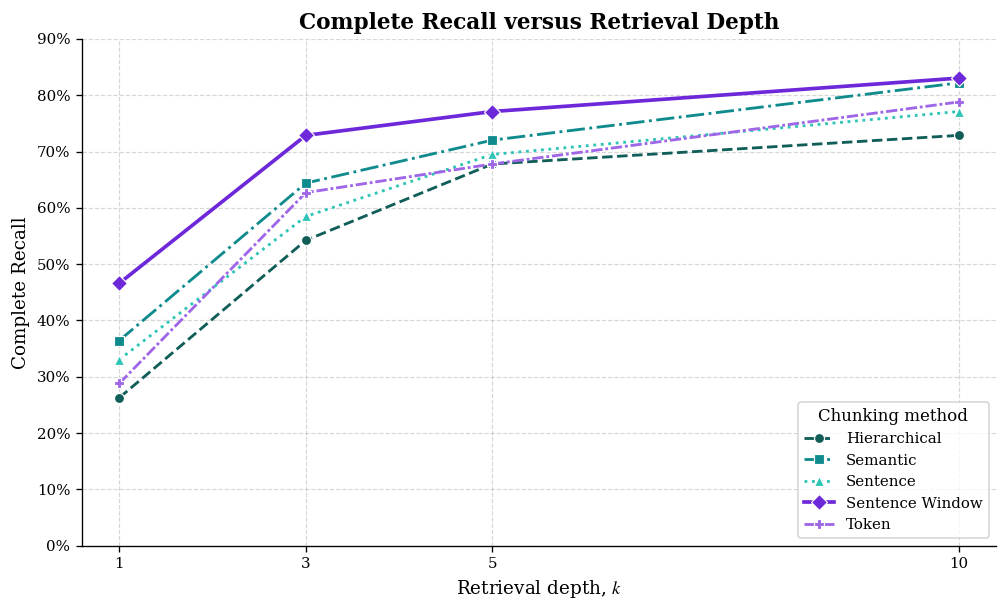

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/complete_recall_by_k_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/complete_recall_by_k_7d74b8baa8.pdf


In [147]:
# Plot Complete Recall as retrieval depth k increases.
k_values = [1, 3, 5, 10]
recall_columns = [f"complete_recall_at_{k}" for k in k_values]
plot_df = summary_df.set_index("method").loc[method_order]

assert plot_df[recall_columns].notna().all().all()
assert plot_df[recall_columns].apply(lambda column: column.between(0, 1)).all().all()

fig, ax = plt.subplots(figsize=(8.5, 5.2), facecolor="white")

for method in method_order:
    recall = plot_df.loc[method, recall_columns].astype(float).to_numpy()

    ax.plot(
        k_values,
        recall,
        label=method_labels[method],
        color=method_colors[method],
        linestyle=method_linestyles[method],
        marker=method_markers[method],
        linewidth=2.2 if method == "sentence_window" else 1.7,
        markersize=7 if method == "sentence_window" else 6,
        markeredgecolor="white",
        markeredgewidth=0.7,
    )

ax.set(
    title="Complete Recall versus Retrieval Depth",
    xlabel=r"Retrieval depth, $k$",
    ylabel="Complete Recall",
    xticks=k_values,
    xlim=(0.6, 10.4),
    ylim=(0, 0.9),
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Chunking method", loc="lower right", frameon=True)

fig.tight_layout()

png_path = FIGURE_FOLDER / f"complete_recall_by_k_{CORPUS_TAG}.png"
pdf_path = FIGURE_FOLDER / f"complete_recall_by_k_{CORPUS_TAG}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

In [119]:
# Figure X. Complete Recall at increasing retrieval depths for five chunking methods. 
# Results are based on 118 held-out single-passage questions using BGE-M3. 
# Sentence Window achieved the highest Complete Recall at every evaluated value of k.

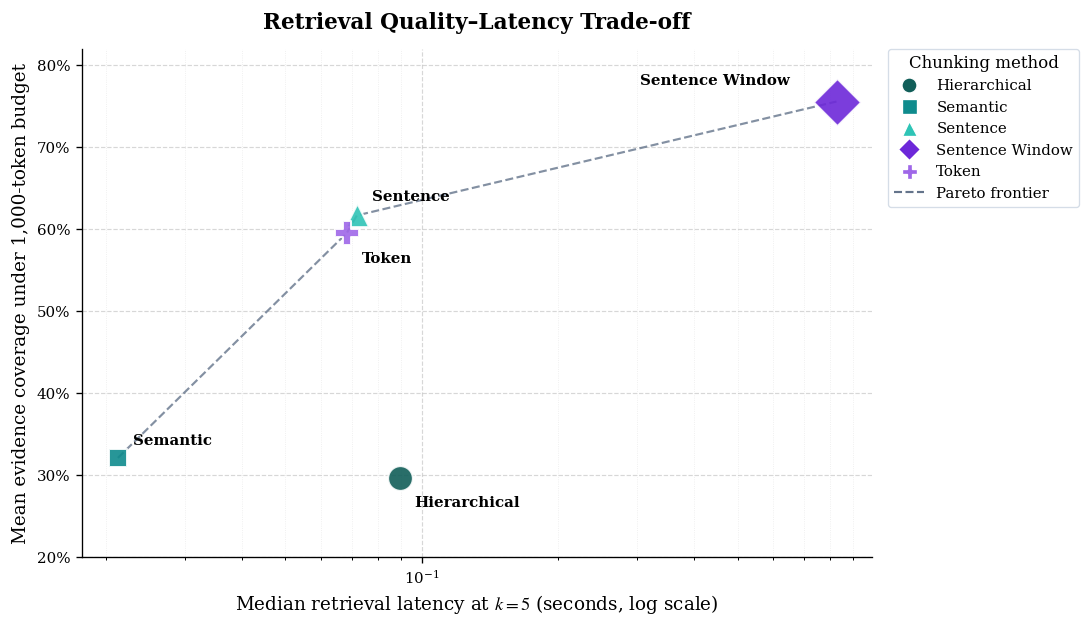

In [148]:
# Compare fixed-budget retrieval quality against median retrieval latency.
tradeoff_df = (
    summary_df.set_index("method")
    .loc[method_order]
    .reset_index()
)

required_columns = [
    "median_latency_at_5",
    "mean_budget_coverage",
    "index_size_bytes",
]

assert tradeoff_df[required_columns].notna().all().all()
assert (tradeoff_df["median_latency_at_5"] > 0).all()
assert tradeoff_df["mean_budget_coverage"].between(0, 1).all()
assert (tradeoff_df["index_size_bytes"] > 0).all()

# Compress index-size differences so every marker remains visible.
log_index_sizes = np.log10(tradeoff_df["index_size_bytes"])
size_range = log_index_sizes.max() - log_index_sizes.min()
tradeoff_df["marker_size"] = (
    180 if size_range == 0
    else 120 + 280 * (log_index_sizes - log_index_sizes.min()) / size_range
)

fig, ax = plt.subplots(figsize=(8.5, 5.5), facecolor="white")

for row in tradeoff_df.itertuples(index=False):
    ax.scatter(
        row.median_latency_at_5,
        row.mean_budget_coverage,
        s=row.marker_size,
        color=method_colors[row.method],
        marker=method_markers[row.method],
        edgecolor="white",
        linewidth=1.2,
        alpha=0.9,
        label="_nolegend_",
        zorder=3,
    )

# Connect methods that are not dominated on both latency and quality.
latency_order = tradeoff_df.sort_values("median_latency_at_5")
frontier_mask = latency_order["mean_budget_coverage"].gt(
    latency_order["mean_budget_coverage"].cummax().shift(fill_value=-np.inf)
)
frontier_df = latency_order[frontier_mask]

ax.plot(
    frontier_df["median_latency_at_5"],
    frontier_df["mean_budget_coverage"],
    color="#64748B",
    linestyle="--",
    linewidth=1.3,
    alpha=0.8,
    label="Pareto frontier",
    zorder=2,
)

label_offsets = {
    "hierarchical": (9, -17),
    "semantic": (9, 8),
    "sentence": (9, 9),
    "sentence_window": (-118, 10),
    "token": (9, -18),
}

for row in tradeoff_df.itertuples(index=False):
    ax.annotate(
        method_labels[row.method],
        (row.median_latency_at_5, row.mean_budget_coverage),
        xytext=label_offsets[row.method],
        textcoords="offset points",
        fontsize=9,
        fontweight="semibold",
    )

ax.set_xscale("log")
ax.set_title("Retrieval Quality–Latency Trade-off", pad=12, fontweight="semibold")
ax.set_xlabel(r"Median retrieval latency at $k=5$ (seconds, log scale)")
ax.set_ylabel("Mean evidence coverage under 1,000-token budget")
ax.set_ylim(0.2, 0.82)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
ax.grid(True, which="minor", axis="x", linestyle=":", linewidth=0.5, alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
legend_handles = [
    Line2D(
        [0], [0],
        marker=method_markers[method],
        linestyle="none",
        markerfacecolor=method_colors[method],
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=9,
        label=method_labels[method],
    )
    for method in method_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        color="#64748B",
        linestyle="--",
        linewidth=1.3,
        label="Pareto frontier",
    )
)

legend = ax.legend(
    handles=legend_handles,
    title="Chunking method",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True,
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#CBD5E1")
legend.get_frame().set_linewidth(0.8)

# Reserve space on the right for the extern

In [121]:
# Figure X. Retrieval quality–latency trade-off across five chunking methods. 
# Quality is measured as mean gold-evidence coverage under the fixed 1,000-token context budget, while latency is the median retrieval time at \(k=5\). 
# Marker area encodes the persisted index size on a logarithmic scale. 
# The dashed line connects Pareto-efficient methods.

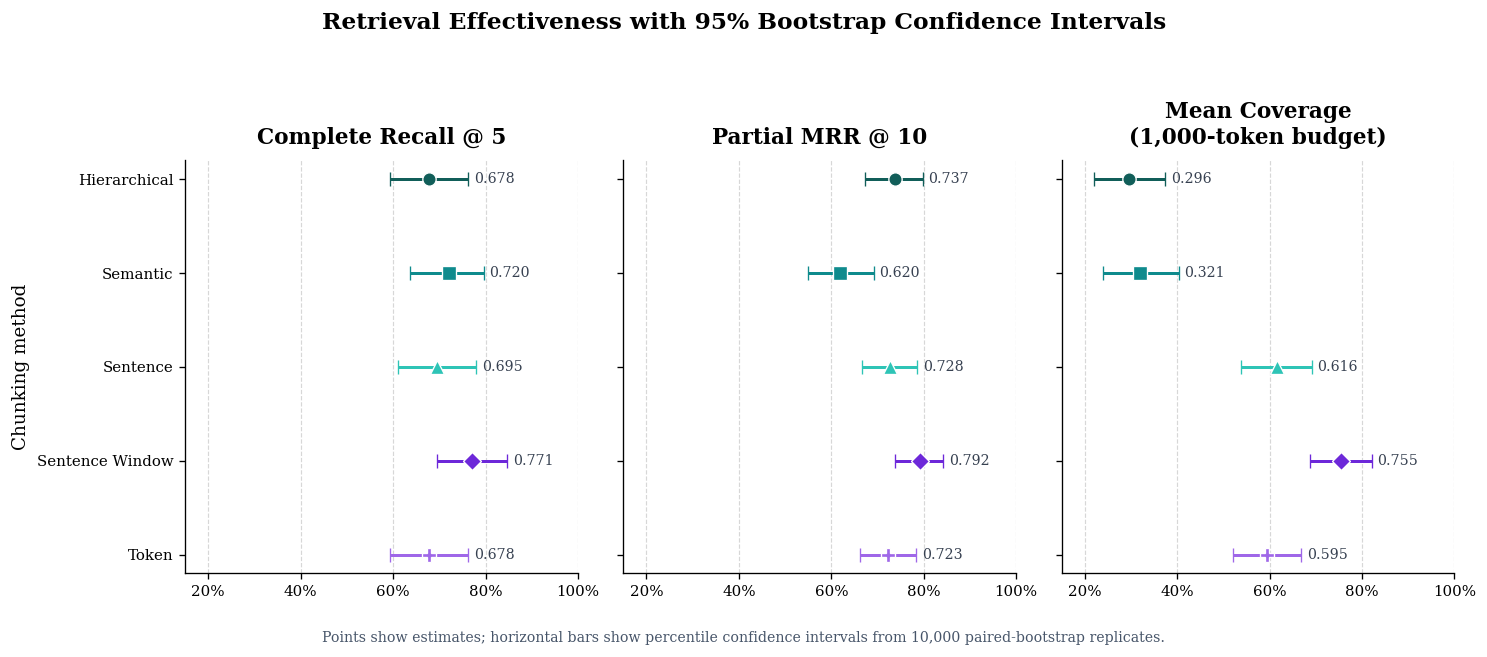

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/bootstrap_forest_plot_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/bootstrap_forest_plot_7d74b8baa8.pdf


In [149]:
forest_metrics = {
    "complete_recall_at_5": "Complete Recall @ 5",
    "partial_mrr_at_10": "Partial MRR @ 10",
    "mean_budget_coverage": "Mean Coverage\n(1,000-token budget)",
}

forest_df = intervals_df[
    intervals_df["metric"].isin(forest_metrics)
].copy()

assert len(forest_df) == len(forest_metrics) * len(method_order)
assert forest_df[["estimate", "ci_lower", "ci_upper"]].notna().all().all()
assert (forest_df["ci_lower"] <= forest_df["estimate"]).all()
assert (forest_df["estimate"] <= forest_df["ci_upper"]).all()

fig, axes = plt.subplots(
    1,
    len(forest_metrics),
    figsize=(12.5, 5.2),
    sharey=True,
)

y_positions = np.arange(len(method_order))

for ax, (metric, title) in zip(axes, forest_metrics.items()):
    metric_df = (
        forest_df[forest_df["metric"].eq(metric)]
        .set_index("method")
        .loc[method_order]
        .reset_index()
    )

    for y, row in enumerate(metric_df.itertuples(index=False)):
        x_error = np.array([[
            row.estimate - row.ci_lower,
            row.ci_upper - row.estimate,
        ]]).T

        ax.errorbar(
            row.estimate,
            y,
            xerr=x_error,
            fmt=method_markers[row.method],
            markersize=8,
            color=method_colors[row.method],
            markeredgecolor="white",
            markeredgewidth=0.8,
            ecolor=method_colors[row.method],
            elinewidth=1.8,
            capsize=4,
            zorder=3,
        )

        ax.text(
            row.ci_upper + 0.012,
            y,
            f"{row.estimate:.3f}",
            va="center",
            fontsize=8.5,
            color="#374151",
        )

    ax.set_title(title, pad=10, fontweight="semibold")
    ax.set_xlim(0.15, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_yticks(y_positions)
axes[0].set_yticklabels([method_labels[method] for method in method_order])
axes[0].set_ylabel("Chunking method")
axes[0].invert_yaxis()

fig.suptitle(
    "Retrieval Effectiveness with 95% Bootstrap Confidence Intervals",
    fontsize=14,
    fontweight="semibold",
    y=1.02,
)

fig.text(
    0.5,
    0.01,
    "Points show estimates; horizontal bars show percentile confidence intervals "
    "from 10,000 paired-bootstrap replicates.",
    ha="center",
    fontsize=8.5,
    color="#475569",
)

fig.tight_layout(rect=[0, 0.05, 1, 0.97])

png_path = FIGURE_FOLDER / f"bootstrap_forest_plot_{CORPUS_TAG}.png"
pdf_path = FIGURE_FOLDER / f"bootstrap_forest_plot_{CORPUS_TAG}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

In [150]:
# Figure X. Retrieval effectiveness with 95% bootstrap confidence intervals. 
# Points represent method-level estimates across 118 held-out questions, 
# and horizontal bars represent percentile confidence intervals obtained from 10,000 paired-bootstrap replicates. 
# Sentence Window produced the highest point estimate for all three metrics. 
# Confidence-interval overlap should not be interpreted as a formal pairwise significance test.

Text(0.5, 0.97, 'Single-Passage Retrieval Evaluation Summary')

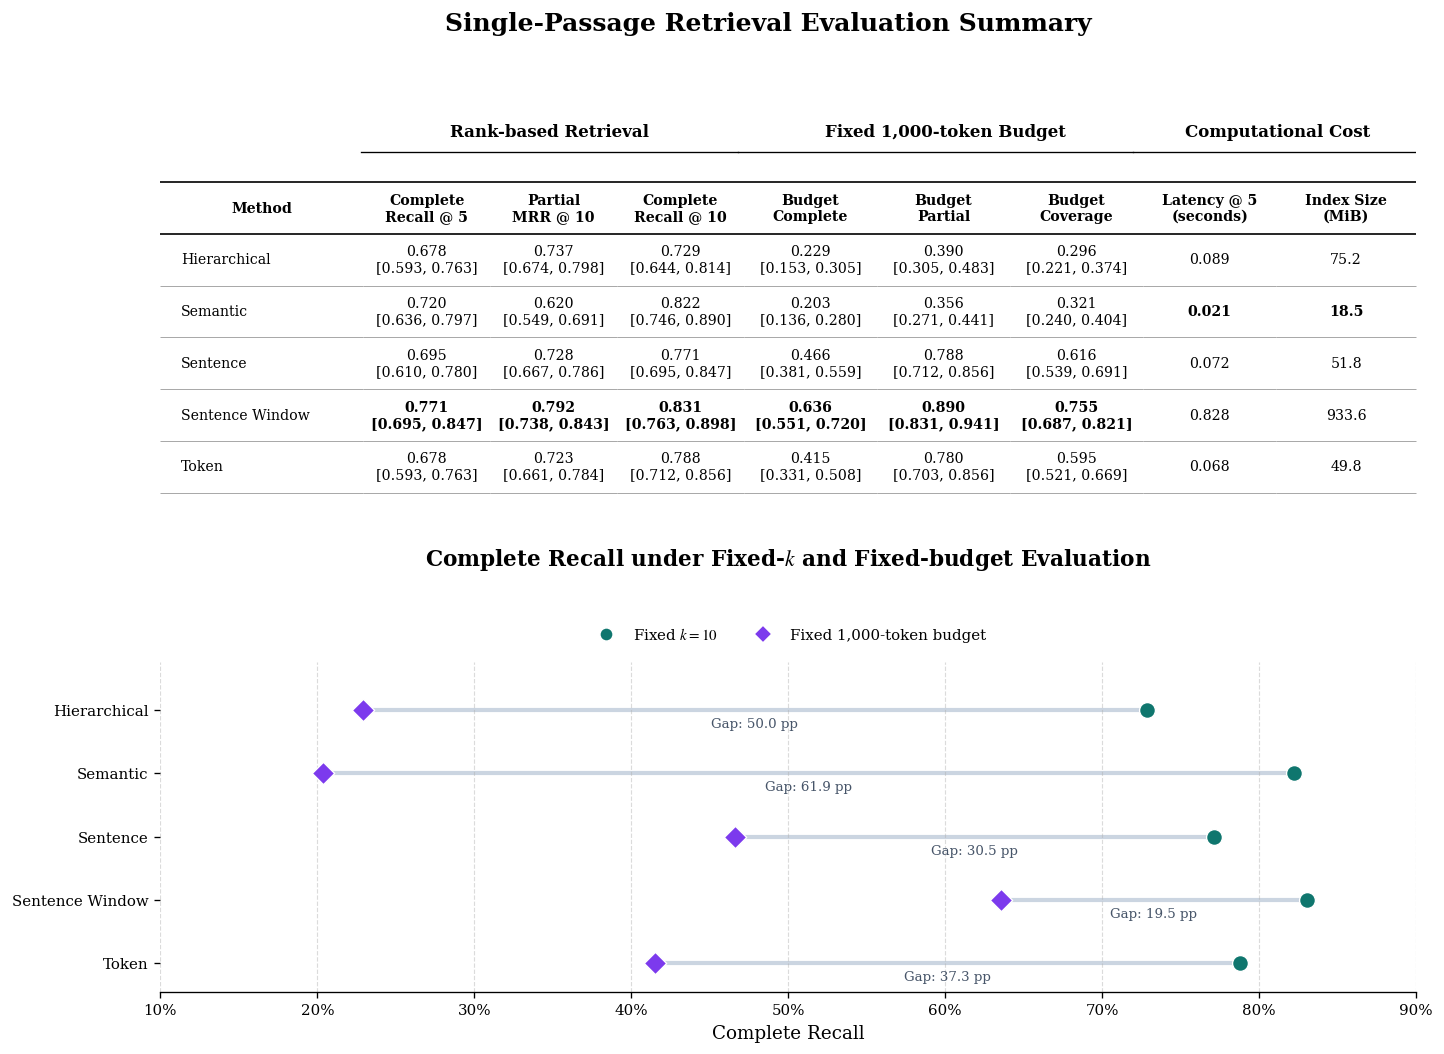

In [155]:
# Composite summary: exact results above, quality-cost relationship below.
metrics = [
    ("complete_recall_at_5", "Complete\nRecall @ 5"),
    ("partial_mrr_at_10", "Partial\nMRR @ 10"),
    ("complete_recall_at_10", "Complete\nRecall @ 10"),
    ("budget_complete_recall", "Budget\nComplete"),
    ("budget_partial_recall", "Budget\nPartial"),
    ("mean_budget_coverage", "Budget\nCoverage"),
]

summary = summary_df.set_index("method").loc[method_order]
intervals = intervals_df.set_index(["metric", "method"])
assert all((metric, method) in intervals.index for metric, _ in metrics for method in method_order)

def format_interval(metric, method):
    row = intervals.loc[(metric, method)]
    return f"{row['estimate']:.3f}\n[{row['ci_lower']:.3f}, {row['ci_upper']:.3f}]"

best_method = {metric: intervals.loc[metric]["estimate"].idxmax() for metric, _ in metrics}
table_rows = [
    [method_labels[method], *[format_interval(metric, method) for metric, _ in metrics],
     f"{summary.loc[method, 'median_latency_at_5']:.3f}",
     f"{summary.loc[method, 'index_size_bytes'] / 2**20:.1f}"]
    for method in method_order
]

fig = plt.figure(figsize=(13.5, 9.5), facecolor="white")
grid = fig.add_gridspec(2, 1, height_ratios=[1.15, 1], hspace=0.48)
table_ax, chart_ax = fig.add_subplot(grid[0]), fig.add_subplot(grid[1])
table_ax.axis("off")

# Black-and-white table with grouped metrics.
headers = ["Method", *[label for _, label in metrics], "Latency @ 5\n(seconds)", "Index Size\n(MiB)"]
table = table_ax.table(cellText=table_rows, colLabels=headers, cellLoc="center",
                       colWidths=[0.16, 0.10, 0.10, 0.10, 0.105, 0.105, 0.105, 0.105, 0.11],
                       bbox=[0, 0, 1, 0.82])
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1, 1.55)

for column in range(len(headers)):
    cell = table[(0, column)]
    cell.set_facecolor("white"); cell.set_text_props(weight="bold", color="black")
    cell.set_edgecolor("black"); cell.set_linewidth(1); cell.visible_edges = "BT"

for row_number, method in enumerate(method_order, start=1):
    for column in range(len(headers)):
        cell = table[(row_number, column)]
        cell.set_facecolor("white"); cell.set_edgecolor("#999999")
        cell.set_linewidth(0.5); cell.visible_edges = "B"
    table[(row_number, 0)].get_text().set_ha("left")
    for column, (metric, _) in enumerate(metrics, start=1):
        if method == best_method[metric]:
            table[(row_number, column)].get_text().set_weight("bold")

# Lower values are preferable for latency and index size.
for column, cost_metric in [(7, "median_latency_at_5"), (8, "index_size_bytes")]:
    method = summary[cost_metric].idxmin()
    table[(method_order.index(method) + 1, column)].get_text().set_weight("bold")

table_ax.text(0.31, 0.94, "Rank-based Retrieval", ha="center", weight="bold", transform=table_ax.transAxes)
table_ax.text(0.625, 0.94, "Fixed 1,000-token Budget", ha="center", weight="bold", transform=table_ax.transAxes)
table_ax.text(0.89, 0.94, "Computational Cost", ha="center", weight="bold", transform=table_ax.transAxes)
table_ax.plot([0.16, 0.46], [0.90, 0.90], color="black", lw=0.8, transform=table_ax.transAxes)
table_ax.plot([0.46, 0.775], [0.90, 0.90], color="black", lw=0.8, transform=table_ax.transAxes)
table_ax.plot([0.775, 1], [0.90, 0.90], color="black", lw=0.8, transform=table_ax.transAxes)

# Compare Complete Recall under fixed-k and fixed-budget evaluation.
comparison = summary[["complete_recall_at_10", "budget_complete_recall"]].copy()
comparison["gap"] = comparison["complete_recall_at_10"] - comparison["budget_complete_recall"]
y = np.arange(len(method_order))

for position, method in enumerate(method_order):
    fixed_k = comparison.loc[method, "complete_recall_at_10"]
    budget = comparison.loc[method, "budget_complete_recall"]

    chart_ax.plot([budget, fixed_k], [position, position], color="#CBD5E1", lw=2.5, zorder=1)
    chart_ax.scatter(fixed_k, position, s=90, color="#0F766E", marker="o",
                     edgecolor="white", linewidth=0.8, zorder=3)
    chart_ax.scatter(budget, position, s=90, color="#7C3AED", marker="D",
                     edgecolor="white", linewidth=0.8, zorder=3)
    chart_ax.text((budget + fixed_k) / 2, position + 0.22,
                  f"Gap: {comparison.loc[method, 'gap'] * 100:.1f} pp",
                  ha="center", va="center", fontsize=8, color="#475569")

chart_ax.set_yticks(y)
chart_ax.set_yticklabels([method_labels[method] for method in method_order])

# Reverse the y-axis manually and reserve space above the first method.
chart_ax.set_ylim(len(method_order) - 0.55, -0.75)
chart_ax.set_xlim(0.1, 0.9)
chart_ax.xaxis.set_major_formatter(PercentFormatter(1))
chart_ax.set_xlabel("Complete Recall")
chart_ax.set_title(
    r"Complete Recall under Fixed-$k$ and Fixed-budget Evaluation",
    fontweight="bold",
    pad=58,
)

chart_ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.45)
chart_ax.spines[["top", "right", "left"]].set_visible(False)

chart_ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Single-Passage Retrieval Evaluation Summary",
    fontsize=15,
    fontweight="bold",
    y=0.97,
)

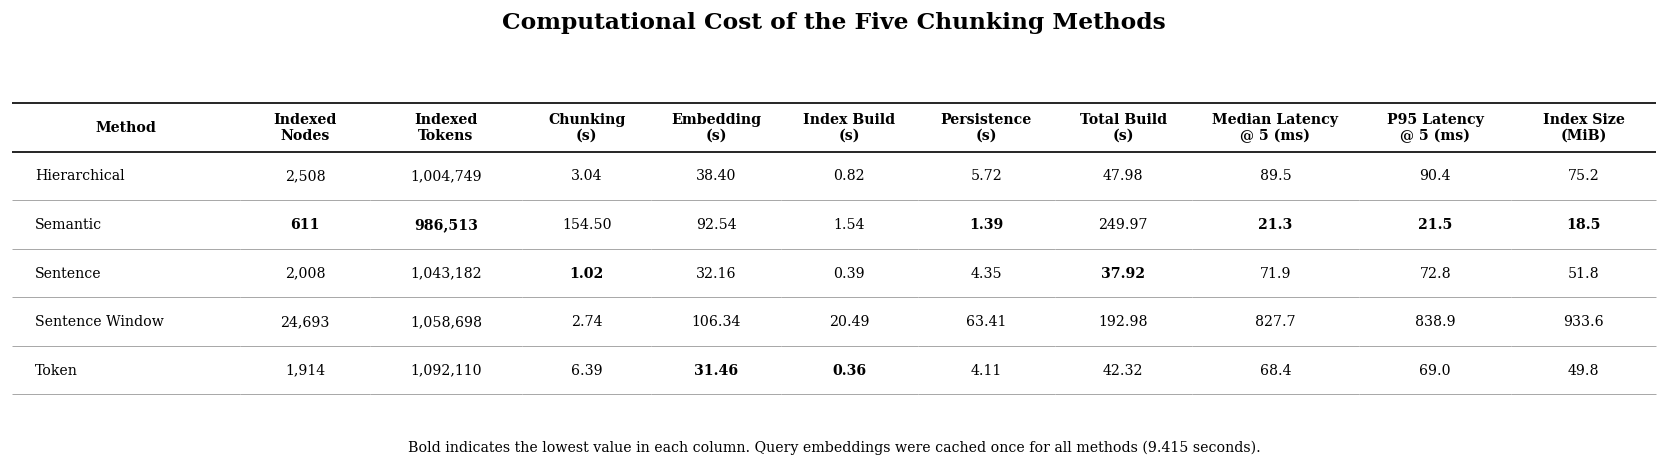

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/computational_cost_table_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/figures/computational_cost_table_7d74b8baa8.pdf


In [157]:
# Summarise indexing workload, construction cost and retrieval latency.
cost = summary_df.set_index("method").loc[method_order].copy()
cost["total_build_seconds"] = cost[
    ["chunking_seconds", "embedding_seconds", "index_construction_seconds", "index_persist_seconds"]
].sum(axis=1)

columns = [
    "indexed_nodes", "indexed_tokens", "chunking_seconds", "embedding_seconds",
    "index_construction_seconds", "index_persist_seconds", "total_build_seconds",
    "median_latency_at_5", "p95_latency_at_5", "index_size_bytes",
]

headers = [
    "Method", "Indexed\nNodes", "Indexed\nTokens", "Chunking\n(s)", "Embedding\n(s)",
    "Index Build\n(s)", "Persistence\n(s)", "Total Build\n(s)",
    "Median Latency\n@ 5 (ms)", "P95 Latency\n@ 5 (ms)", "Index Size\n(MiB)",
]

def format_cost(method, column):
    value = cost.loc[method, column]
    if column in {"indexed_nodes", "indexed_tokens"}:
        return f"{int(value):,}"
    if column in {"median_latency_at_5", "p95_latency_at_5"}:
        return f"{value * 1000:.1f}"
    if column == "index_size_bytes":
        return f"{value / 2**20:.1f}"
    return f"{value:.2f}"

rows = [[method_labels[method], *[format_cost(method, column) for column in columns]]
        for method in method_order]
lowest_method = {column: cost[column].idxmin() for column in columns}

fig, ax = plt.subplots(figsize=(14, 4.1), facecolor="white")
ax.axis("off")

table = ax.table(
    cellText=rows, colLabels=headers, cellLoc="center",
    colWidths=[0.15, 0.085, 0.10, 0.085, 0.085, 0.09, 0.09, 0.09, 0.11, 0.10, 0.095],
    bbox=[0, 0.16, 1, 0.70],
)
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1, 1.5)

# Use a print-friendly black-and-white style.
for column in range(len(headers)):
    cell = table[(0, column)]
    cell.set_facecolor("white"); cell.set_text_props(weight="bold")
    cell.set_edgecolor("black"); cell.set_linewidth(1); cell.visible_edges = "BT"

for row_number, method in enumerate(method_order, start=1):
    for column in range(len(headers)):
        cell = table[(row_number, column)]
        cell.set_facecolor("white"); cell.set_edgecolor("#999999")
        cell.set_linewidth(0.5); cell.visible_edges = "B"
    table[(row_number, 0)].get_text().set_ha("left")
    for column, metric in enumerate(columns, start=1):
        if method == lowest_method[metric]:
            table[(row_number, column)].get_text().set_weight("bold")

shared_path = EVALUATION_RUN_FOLDER / f"evaluation_shared_costs_{CORPUS_TAG}.json"
shared_cost = json.loads(shared_path.read_text(encoding="utf-8"))

fig.suptitle("Computational Cost of the Five Chunking Methods", fontsize=14, fontweight="bold", y=0.95)
fig.text(
    0.5, 0.055,
    f"Bold indicates the lowest value in each column. Query embeddings were cached once "
    f"for all methods ({shared_cost['query_embedding_seconds']:.3f} seconds).",
    ha="center", fontsize=8.5,
)
fig.tight_layout()

png_path = FIGURE_FOLDER / f"computational_cost_table_{CORPUS_TAG}.png"
pdf_path = FIGURE_FOLDER / f"computational_cost_table_{CORPUS_TAG}.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

In [159]:
# Table X. Computational cost of the five frozen chunking methods. 
# Total build time comprises chunking, embedding, index construction and persistence. 
# Retrieval latency excludes the shared query-embedding preparation, which was performed once and reused across all methods.